## Modelling strategy

In this section, we estimate two prediction settings in order to distinguish between **next-day effects** and **same-day premarket effects**.

**Next-day modelling** asks whether information from Trump’s posts on day *t* helps predict market outcomes on day *t+1*. In this setup, the target variables are `next_market_up` for classification and `next_log_return` for regression. The goal is to test whether posting activity, sentiment, engagement, stylistic features, topic indicators, and semantic features from the current day contain information about the following trading day.

**Premarket modelling** asks whether information available **before the market opens** can help predict returns on the **same trading day**. Here, the target variables are `market_up` and `log_return`, while the input features are restricted to premarket variables such as `*_premarket` sentiment, posting counts, and engagement measures, together with lagged market controls. The purpose of this setup is to test whether Trump-related signals have immediate predictive value that could, in principle, be observable before trading starts.

We keep these two modelling settings separate because they answer different research questions. Next-day modelling captures whether market effects emerge with a short delay, while premarket modelling captures whether there is an observable signal already available before the trading session begins.

Within each setting, we compare **classification** and **regression** tasks. Classification focuses on the direction of the market move, that is, whether the market goes up or down. Regression focuses on the magnitude of the move, that is, the size of the return. This distinction is important because predicting direction is often easier than predicting the exact return size.

To evaluate the models in a realistic way, we use a **chronological split** rather than a random train-test split. The training period covers **2009–2020**, the validation period covers **2022–2023**, and the final test period covers **2024–2025**. This preserves temporal order and avoids look-ahead bias. In addition, we apply **TimeSeriesSplit cross-validation** within the training data to make model selection more robust.

Finally, we compare different feature sets to test whether more complex text information adds predictive value beyond standard market controls. We start with a market-only baseline, then add simple NLP variables such as posting frequency and sentiment, richer NLP features such as stylistic variables and topic indicators, and finally semantic features such as embedding diversity, novelty scores, and BERTopic cluster dummies.

### 1. Setup, load data, define splits and feature sets

In [17]:
# 1) Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit, cross_val_score, train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge, ElasticNet
from sklearn.svm import LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.neural_network import MLPClassifier, MLPRegressor


from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [18]:
# 2) Global settings
SEED = 42
N_SPLITS_CV = 5
RUN_MLP = False   # set True if you also want a neural-network benchmark

In [23]:
# 3) Paths and data loading

PROJECT_ROOT = Path("..").resolve()
FEATURES_DIR = PROJECT_ROOT / "3_feature_engineering" / "features"
FEATURE_MATRIX_PATH = FEATURES_DIR / "feature_matrix.csv"

print("Project root:", PROJECT_ROOT)
print("Features dir exists:", FEATURES_DIR.exists())
print("Feature matrix exists:", FEATURE_MATRIX_PATH.exists())

if not FEATURE_MATRIX_PATH.exists():
    raise FileNotFoundError(f"Feature matrix not found: {FEATURE_MATRIX_PATH}")

# Load feature matrix
df = pd.read_csv(FEATURE_MATRIX_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

# Drop helper columns that should not be used directly as model inputs
df = df.drop(columns=["date_only", "dominant_cluster"], errors="ignore")

# Leakage-safe market lag features
# These features are needed especially for premarket models.
# Premarket models must not use same-day market information.

if "log_return" in df.columns and "return_lag1" not in df.columns:
    df["return_lag1"] = df["log_return"].shift(1)

if "log_return" in df.columns and "return_lag2" not in df.columns:
    df["return_lag2"] = df["log_return"].shift(2)

if "vol_5d" in df.columns and "vol_5d_lag1" not in df.columns:
    df["vol_5d_lag1"] = df["vol_5d"].shift(1)

if "vol_20d" in df.columns and "vol_20d_lag1" not in df.columns:
    df["vol_20d_lag1"] = df["vol_20d"].shift(1)

if "intraday_range" in df.columns and "range_lag1" not in df.columns:
    df["range_lag1"] = df["intraday_range"].shift(1)

print("Lagged market columns available:")
print("return_lag1:", "return_lag1" in df.columns)
print("return_lag2:", "return_lag2" in df.columns)
print("vol_5d_lag1:", "vol_5d_lag1" in df.columns)
print("vol_20d_lag1:", "vol_20d_lag1" in df.columns)
print("range_lag1:", "range_lag1" in df.columns)

# Identify topic and cluster columns

topic_cols_all = [c for c in df.columns if c.startswith("topic_")]

topic_cols_daily = [
    c for c in topic_cols_all
    if not c.endswith("_premarket")
]

topic_cols_premarket = [
    c for c in topic_cols_all
    if c.endswith("_premarket")
]

cluster_cols = [
    c for c in df.columns
    if c.startswith("cluster_")
]

# Convert binary indicator columns to integers where possible
for col in cluster_cols + topic_cols_all:
    df[col] = df[col].fillna(0).astype(int)

# Premarket missing values usually mean: no premarket post
premarket_cols = [c for c in df.columns if c.endswith("_premarket")]
if premarket_cols:
    df[premarket_cols] = df[premarket_cols].fillna(0)

# Explicit indicator for premarket activity
if "post_count_premarket" in df.columns:
    df["has_premarket_post"] = (df["post_count_premarket"] > 0).astype(int)
else:
    df["has_premarket_post"] = 0

# Basic diagnostics

required_columns = [
    "date",
    "log_return",
    "next_log_return",
    "market_up",
    "next_market_up",
    "return_lag1",
    "return_lag2",
    "vol_5d_lag1",
    "vol_20d_lag1"
]

missing_required = [c for c in required_columns if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Daily topic columns:", topic_cols_daily)
print("Premarket topic columns:", topic_cols_premarket)
print("Cluster columns:", len(cluster_cols))

display(df.head())

Project root: C:\Users\ChristophSchilling\OneDrive - BLAID GmbH\Dokumente\GitHub\trump-tweets-nlp
Features dir exists: True
Feature matrix exists: True
Lagged market columns available:
return_lag1: True
return_lag2: True
vol_5d_lag1: True
vol_20d_lag1: True
range_lag1: True
Shape: (3526, 98)
Date range: 2009-05-04 00:00:00 to 2026-01-08 00:00:00
Daily topic columns: ['topic_elections', 'topic_rallies_campaign', 'topic_praise_thanks', 'topic_motivational', 'topic_media_attacks', 'topic_legal', 'topic_trump_identity', 'topic_rallies_nationalism', 'topic_trade_geopolitics', 'topic_economy_markets', 'topic_motivational_business', 'topic_endorsements', 'topic_sports', 'topic_book_promotion', 'topic_energy_environment']
Premarket topic columns: ['topic_elections_premarket', 'topic_rallies_campaign_premarket', 'topic_praise_thanks_premarket', 'topic_motivational_premarket', 'topic_media_attacks_premarket', 'topic_legal_premarket', 'topic_trump_identity_premarket', 'topic_rallies_nationalism_p

,date,Close,High,Low,Open,Volume,log_return,abs_return,intraday_range,next_log_return,...,cluster_topic_4,cluster_topic_5,cluster_topic_6,cluster_topic_7,cluster_topic_8,cluster_topic_9,vol_5d_lag1,vol_20d_lag1,range_lag1,has_premarket_post
0,2009-05-04,907.24,907.85,879.21,879.21,7038840000,0.033868,0.033868,0.032575,-0.003792,...,0,0,0,0,0,0,NaN,NaN,NaN,0
1,2009-05-08,929.23,930.17,909.03,909.03,8163280000,0.024069,0.024069,0.023256,-0.021512,...,0,0,0,0,0,0,NaN,NaN,0.032575,1
2,2009-05-12,908.35,915.57,896.46,910.52,6871750000,-0.000979,0.000979,0.020988,-0.026895,...,0,0,0,0,0,0,0.019603,NaN,0.023256,0
3,2009-05-13,883.92,905.40,882.80,905.40,7091820000,-0.026895,0.026895,0.024961,0.010352,...,0,0,0,0,0,0,0.019452,NaN,0.020988,0
4,2009-05-14,893.07,898.36,882.52,884.24,6134870000,0.010352,0.010352,0.017914,-0.011410,...,0,0,0,0,1,0,0.020273,NaN,0.024961,0


In [24]:
# 4) Chronological split

def assign_split(date_value):
    if pd.Timestamp("2009-01-01") <= date_value <= pd.Timestamp("2020-12-31"):
        return "train"
    elif pd.Timestamp("2022-01-01") <= date_value <= pd.Timestamp("2023-12-31"):
        return "valid"
    elif pd.Timestamp("2024-01-01") <= date_value <= pd.Timestamp("2025-12-31"):
        return "test"
    else:
        return "unused"

df["split"] = df["date"].apply(assign_split)
model_df = df[df["split"] != "unused"].copy()

print("Full feature matrix rows:", len(df))
print("Model rows after split filter:", len(model_df))
print(model_df["split"].value_counts())

display(
    model_df.groupby("split")["date"].agg(["min", "max", "count"])
)

Full feature matrix rows: 3526
Model rows after split filter: 3516
split
train    2596
test      500
valid     420
Name: count, dtype: int64


,min,max,count
split,,,
test,2024-01-02,2025-12-31,500
train,2009-05-04,2020-12-31,2596
valid,2022-02-14,2023-12-29,420


In [26]:
# 5) Feature groups

def keep_existing(columns, frame, label="feature set", strict=False):
    """
    Keep only columns that exist in the dataframe.
    Print missing columns so outdated feature names do not disappear silently.
    """
    existing = [c for c in columns if c in frame.columns]
    missing = [c for c in columns if c not in frame.columns]

    if missing:
        print(f"[WARNING] Missing columns in {label}:")
        for c in missing:
            print(f"  - {c}")

        if strict:
            raise ValueError(f"Missing columns in {label}: {missing}")

    return existing

# Market-only controls

market_base = [
    "return_lag1",
    "return_lag2",
    "vol_5d",
    "vol_20d"
]

# Leakage-safe market controls for premarket models.
# These must only use information available before market open.
market_base_premarket = [
    "return_lag1",
    "return_lag2",
    "vol_5d_lag1",
    "vol_20d_lag1"
]

# Simple daily NLP features

simple_daily_nlp = [
    "post_count",
    "vader_mean",
    "vader_std",
    "finbert_mean",
    "finbert_std",
    "max_engagement",
    "mean_word_count"
]

# Current topic names from the cleaned Feature Engineering pipeline

current_daily_topics = [
    "topic_trump_identity",
    "topic_elections",
    "topic_rallies_nationalism",
    "topic_praise_thanks",
    "topic_trade_geopolitics",
    "topic_economy_markets",
    "topic_motivational_business",
    "topic_endorsements",
    "topic_sports",
    "topic_book_promotion",
    "topic_energy_environment"
]

current_premarket_topics = [
    f"{c}_premarket"
    for c in current_daily_topics
]

# These are the only topics treated as economically market-relevant.
market_relevant_topics = [
    "topic_trade_geopolitics",
    "topic_economy_markets"
]

market_relevant_topics_premarket = [
    f"{c}_premarket"
    for c in market_relevant_topics
]


# Diagnostic: stale topic columns still present in feature_matrix.csv

stale_topic_cols = [
    "topic_rallies_campaign",
    "topic_motivational",
    "topic_media_attacks",
    "topic_legal",
    "topic_rallies_campaign_premarket",
    "topic_motivational_premarket",
    "topic_media_attacks_premarket",
    "topic_legal_premarket"
]

stale_topic_cols_present = [
    c for c in stale_topic_cols
    if c in model_df.columns
]

if stale_topic_cols_present:
    print("[INFO] Stale topic columns found in feature_matrix.csv but ignored in modelling:")
    for c in stale_topic_cols_present:
        print(f"  - {c}")


# Advanced daily NLP features

advanced_daily_nlp = [
    "vader_max_pos",
    "vader_max_neg",
    "caps_ratio_mean",
    "exclamation_mean",
    "exclamation_max",
    "vader_3d_rolling",
    "vader_7d_rolling",
    "vader_momentum"
] + current_daily_topics


# Semantic features

semantic_daily = [
    "emb_diversity",
    "novelty_score"
] + cluster_cols


# Premarket NLP features

simple_premarket_nlp = [
    "has_premarket_post",
    "post_count_premarket",
    "vader_mean_premarket",
    "vader_std_premarket",
    "finbert_mean_premarket",
    "finbert_std_premarket",
    "max_engagement_premarket",
    "mean_word_count_premarket"
]

advanced_premarket_nlp = [
    "vader_max_pos_premarket",
    "vader_max_neg_premarket",
    "caps_ratio_mean_premarket",
    "exclamation_mean_premarket",
    "exclamation_max_premarket"
] + current_premarket_topics


# Next-day feature sets

next_day_feature_sets = {
    "market_only": keep_existing(
        market_base,
        model_df,
        label="next_day: market_only",
        strict=True
    ),
    "market_plus_simple_nlp": keep_existing(
        market_base + simple_daily_nlp,
        model_df,
        label="next_day: market_plus_simple_nlp"
    ),
    "market_plus_full_nlp": keep_existing(
        market_base + simple_daily_nlp + advanced_daily_nlp,
        model_df,
        label="next_day: market_plus_full_nlp"
    ),
    "market_plus_semantic": keep_existing(
        market_base + simple_daily_nlp + advanced_daily_nlp + semantic_daily,
        model_df,
        label="next_day: market_plus_semantic"
    )
}


# Premarket feature sets

premarket_feature_sets = {
    "market_only": keep_existing(
        market_base_premarket,
        model_df,
        label="premarket: market_only",
        strict=True
    ),
    "market_plus_simple_premarket": keep_existing(
        market_base_premarket + simple_premarket_nlp,
        model_df,
        label="premarket: market_plus_simple_premarket"
    ),
    "market_plus_full_premarket": keep_existing(
        market_base_premarket + simple_premarket_nlp + advanced_premarket_nlp,
        model_df,
        label="premarket: market_plus_full_premarket"
    )
}


# Summary diagnostics

print("Next-day feature sets:")
for k, v in next_day_feature_sets.items():
    print(f"{k}: {len(v)} features")

print("\nPremarket feature sets:")
for k, v in premarket_feature_sets.items():
    print(f"{k}: {len(v)} features")

print("\nMarket-relevant daily topics used later for event days:")
print(keep_existing(
    market_relevant_topics,
    model_df,
    label="market_relevant_topics",
    strict=True
))

print("\nMarket-relevant premarket topics:")
print(keep_existing(
    market_relevant_topics_premarket,
    model_df,
    label="market_relevant_topics_premarket"
))

[INFO] Stale topic columns found in feature_matrix.csv but ignored in modelling:
  - topic_rallies_campaign
  - topic_motivational
  - topic_media_attacks
  - topic_legal
  - topic_rallies_campaign_premarket
  - topic_motivational_premarket
  - topic_media_attacks_premarket
  - topic_legal_premarket
Next-day feature sets:
market_only: 4 features
market_plus_simple_nlp: 11 features
market_plus_full_nlp: 30 features
market_plus_semantic: 47 features

Premarket feature sets:
market_only: 4 features
market_plus_simple_premarket: 12 features
market_plus_full_premarket: 28 features

Market-relevant daily topics used later for event days:
['topic_trade_geopolitics', 'topic_economy_markets']

Market-relevant premarket topics:
['topic_trade_geopolitics_premarket', 'topic_economy_markets_premarket']


In [27]:
# 6) Modeling scenarios

SCENARIOS = {
    # Predict next trading day's market direction using information from day t
    "next_day_classification": {
        "task": "classification",
        "target": "next_market_up",
        "feature_sets": next_day_feature_sets,
        "description": "Predict whether the S&P 500 is up on the next trading day."
    },

    # Predict next trading day's return magnitude using information from day t
    "next_day_regression": {
        "task": "regression",
        "target": "next_log_return",
        "feature_sets": next_day_feature_sets,
        "description": "Predict next-day S&P 500 log return."
    },

    # Predict same-day market direction using only premarket text features and lagged market controls
    "premarket_classification": {
        "task": "classification",
        "target": "market_up",
        "feature_sets": premarket_feature_sets,
        "description": "Predict same-day S&P 500 direction using only premarket information."
    },

    # Predict same-day return magnitude using only premarket text features and lagged market controls
    "premarket_regression": {
        "task": "regression",
        "target": "log_return",
        "feature_sets": premarket_feature_sets,
        "description": "Predict same-day S&P 500 log return using only premarket information."
    }
}

for scenario_name, config in SCENARIOS.items():
    target = config["target"]
    if target not in model_df.columns:
        raise ValueError(f"Target column missing for {scenario_name}: {target}")

    print(f"{scenario_name}")
    print(f"  task: {config['task']}")
    print(f"  target: {target}")
    print(f"  feature sets: {list(config['feature_sets'].keys())}")
    print(f"  description: {config['description']}")

next_day_classification
  task: classification
  target: next_market_up
  feature sets: ['market_only', 'market_plus_simple_nlp', 'market_plus_full_nlp', 'market_plus_semantic']
  description: Predict whether the S&P 500 is up on the next trading day.
next_day_regression
  task: regression
  target: next_log_return
  feature sets: ['market_only', 'market_plus_simple_nlp', 'market_plus_full_nlp', 'market_plus_semantic']
  description: Predict next-day S&P 500 log return.
premarket_classification
  task: classification
  target: market_up
  feature sets: ['market_only', 'market_plus_simple_premarket', 'market_plus_full_premarket']
  description: Predict same-day S&P 500 direction using only premarket information.
premarket_regression
  task: regression
  target: log_return
  feature sets: ['market_only', 'market_plus_simple_premarket', 'market_plus_full_premarket']
  description: Predict same-day S&P 500 log return using only premarket information.


### 2. Helper functions for model training and evaluation

In [28]:
# 7) Helper functions

def make_model(task, model_name, random_state=SEED):
    """
    Build a sklearn pipeline:
    1. median imputation
    2. scaling for scale-sensitive models
    3. estimator
    """

    scale_models = {
        "logreg",
        "linear_svm",
        "ridge",
        "elastic_net",
        "mlp"
    }

    if task == "classification":
        model_dict = {
            "dummy": DummyClassifier(strategy="most_frequent"),

            "logreg": LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=random_state
            ),

            "linear_svm": LinearSVC(
                class_weight="balanced",
                dual=False,
                max_iter=5000,
                random_state=random_state
            ),

            "random_forest": RandomForestClassifier(
                n_estimators=200,
                min_samples_leaf=5,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=random_state
            ),

            "gradient_boosting": GradientBoostingClassifier(
                random_state=random_state
            )
        }

        if RUN_MLP:
            model_dict["mlp"] = MLPClassifier(
                hidden_layer_sizes=(64, 32),
                alpha=1e-3,
                max_iter=500,
                random_state=random_state
            )

    elif task == "regression":
        model_dict = {
            "dummy": DummyRegressor(strategy="mean"),

            "ridge": Ridge(alpha=1.0),

            "elastic_net": ElasticNet(
                alpha=0.01,
                l1_ratio=0.5,
                max_iter=5000,
                random_state=random_state
            ),

            "random_forest": RandomForestRegressor(
                n_estimators=200,
                min_samples_leaf=5,
                n_jobs=-1,
                random_state=random_state
            ),

            "gradient_boosting": GradientBoostingRegressor(
                random_state=random_state
            )
        }

        if RUN_MLP:
            model_dict["mlp"] = MLPRegressor(
                hidden_layer_sizes=(64, 32),
                alpha=1e-3,
                max_iter=500,
                random_state=random_state
            )

    else:
        raise ValueError("task must be 'classification' or 'regression'")

    if model_name not in model_dict:
        available_models = list(model_dict.keys())
        raise ValueError(
            f"Unknown model_name '{model_name}' for task '{task}'. "
            f"Available models: {available_models}"
        )

    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if model_name in scale_models:
        steps.append(("scaler", StandardScaler()))

    steps.append(("model", model_dict[model_name]))

    return Pipeline(steps)

In [29]:
# 8) Scoring helpers

def get_classification_score_signal(fitted_model, X):
    """
    Return continuous scores for ROC-AUC.
    Uses predict_proba if available, otherwise decision_function.
    Falls back to class predictions only if no score method exists.
    """

    if hasattr(fitted_model, "predict_proba"):
        proba = fitted_model.predict_proba(X)

        if proba.shape[1] == 2:
            return proba[:, 1]

        return proba[:, -1]

    if hasattr(fitted_model, "decision_function"):
        score = fitted_model.decision_function(X)

        if np.ndim(score) > 1:
            return score[:, 1]

        return score

    return fitted_model.predict(X)


def safe_roc_auc(y_true, y_score):
    """
    Compute ROC-AUC safely.
    ROC-AUC is undefined if y_true contains only one class.
    """

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, y_score)


def evaluate_classification(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": safe_roc_auc(y_true, y_score)
    }


def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        "rmse": rmse,
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }


def get_cv_scoring(task):
    if task == "classification":
        return "roc_auc"

    if task == "regression":
        return "neg_mean_squared_error"

    raise ValueError("task must be 'classification' or 'regression'")


def sort_results(results_df, task):
    if task == "classification":
        return results_df.sort_values(
            by=["valid_roc_auc", "valid_balanced_accuracy", "cv_mean"],
            ascending=[False, False, False],
            na_position="last"
        )

    return results_df.sort_values(
        by=["valid_rmse", "valid_mae", "cv_mean_rmse"],
        ascending=[True, True, True],
        na_position="last"
    )

In [30]:
# 9) Training and testing functions

def _safe_nanmean(values):
    values = np.asarray(values, dtype=float)
    if np.all(np.isnan(values)):
        return np.nan
    return np.nanmean(values)


def _safe_nanstd(values):
    values = np.asarray(values, dtype=float)
    if np.all(np.isnan(values)):
        return np.nan
    return np.nanstd(values)


def _validate_feature_set(feature_cols, feature_set_name, scenario_name):
    if not feature_cols:
        raise ValueError(
            f"No features available for feature set '{feature_set_name}' "
            f"in scenario '{scenario_name}'."
        )


def _validate_target_column(data, target, scenario_name):
    if target not in data.columns:
        raise ValueError(
            f"Target '{target}' not found for scenario '{scenario_name}'."
        )


def run_model_search(data, scenario_name, scenario_config):
    """
    1. Train on train split
    2. Run TimeSeriesSplit CV inside the train split
    3. Fit on the full train split
    4. Evaluate on the validation split
    """

    task = scenario_config["task"]
    target = scenario_config["target"]
    feature_sets = scenario_config["feature_sets"]

    _validate_target_column(data, target, scenario_name)

    train_df = data[data["split"] == "train"].dropna(subset=[target]).copy()
    valid_df = data[data["split"] == "valid"].dropna(subset=[target]).copy()

    if train_df.empty:
        raise ValueError(f"No training rows available for scenario '{scenario_name}'.")

    if valid_df.empty:
        raise ValueError(f"No validation rows available for scenario '{scenario_name}'.")

    if task == "classification":
        if train_df[target].nunique() < 2:
            raise ValueError(
                f"Training target for scenario '{scenario_name}' contains fewer than two classes."
            )

        model_names = [
            "dummy",
            "logreg",
            "linear_svm",
            "random_forest",
            "gradient_boosting"
        ]

        if RUN_MLP:
            model_names.append("mlp")

    elif task == "regression":
        model_names = [
            "dummy",
            "ridge",
            "elastic_net",
            "random_forest",
            "gradient_boosting"
        ]

        if RUN_MLP:
            model_names.append("mlp")

    else:
        raise ValueError("task must be 'classification' or 'regression'")

    n_splits = min(N_SPLITS_CV, len(train_df) - 1)

    if n_splits < 2:
        raise ValueError(
            f"Not enough training observations for TimeSeriesSplit in scenario '{scenario_name}'."
        )

    rows = []
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_scoring = get_cv_scoring(task)

    for feature_set_name, feature_cols in feature_sets.items():
        _validate_feature_set(feature_cols, feature_set_name, scenario_name)

        X_train = train_df[feature_cols]
        y_train = train_df[target]

        X_valid = valid_df[feature_cols]
        y_valid = valid_df[target]

        for model_name in model_names:
            model = make_model(task, model_name)

            cv_scores = cross_val_score(
                estimator=model,
                X=X_train,
                y=y_train,
                cv=tscv,
                scoring=cv_scoring,
                n_jobs=1,
                error_score=np.nan
            )

            model.fit(X_train, y_train)
            y_pred = model.predict(X_valid)

            row = {
                "scenario": scenario_name,
                "task": task,
                "target": target,
                "feature_set": feature_set_name,
                "n_features": len(feature_cols),
                "model": model_name
            }

            if task == "classification":
                row["cv_mean"] = _safe_nanmean(cv_scores)
                row["cv_std"] = _safe_nanstd(cv_scores)

                y_score = get_classification_score_signal(model, X_valid)
                valid_metrics = evaluate_classification(y_valid, y_pred, y_score)

            else:
                cv_rmse_scores = np.sqrt(-cv_scores)

                row["cv_mean_rmse"] = _safe_nanmean(cv_rmse_scores)
                row["cv_std_rmse"] = _safe_nanstd(cv_rmse_scores)

                valid_metrics = evaluate_regression(y_valid, y_pred)

            for metric_name, metric_value in valid_metrics.items():
                row[f"valid_{metric_name}"] = metric_value

            rows.append(row)

    results_df = pd.DataFrame(rows)

    if results_df.empty:
        raise ValueError(f"No model results produced for scenario '{scenario_name}'.")

    results_df = sort_results(results_df, task).reset_index(drop=True)

    return results_df


def refit_best_and_test(data, scenario_name, scenario_config, validation_results):
    """
    1. Pick the best validation model
    2. Refit it on train + validation
    3. Evaluate once on the final test set
    """

    task = scenario_config["task"]
    target = scenario_config["target"]
    feature_sets = scenario_config["feature_sets"]

    _validate_target_column(data, target, scenario_name)

    if validation_results.empty:
        raise ValueError(f"Validation results are empty for scenario '{scenario_name}'.")

    best_row = validation_results.iloc[0].copy()
    best_feature_set = best_row["feature_set"]
    best_model_name = best_row["model"]

    if best_feature_set not in feature_sets:
        raise ValueError(
            f"Selected feature set '{best_feature_set}' is not defined for scenario '{scenario_name}'."
        )

    feature_cols = feature_sets[best_feature_set]
    _validate_feature_set(feature_cols, best_feature_set, scenario_name)

    train_valid_df = (
        data[data["split"].isin(["train", "valid"])]
        .dropna(subset=[target])
        .copy()
    )

    test_df = (
        data[data["split"] == "test"]
        .dropna(subset=[target])
        .copy()
    )

    if train_valid_df.empty:
        raise ValueError(f"No train+validation rows available for scenario '{scenario_name}'.")

    if test_df.empty:
        raise ValueError(f"No test rows available for scenario '{scenario_name}'.")

    if task == "classification" and train_valid_df[target].nunique() < 2:
        raise ValueError(
            f"Train+validation target for scenario '{scenario_name}' contains fewer than two classes."
        )

    X_train_valid = train_valid_df[feature_cols]
    y_train_valid = train_valid_df[target]

    X_test = test_df[feature_cols]
    y_test = test_df[target]

    final_model = make_model(task, best_model_name)
    final_model.fit(X_train_valid, y_train_valid)
    y_pred = final_model.predict(X_test)

    result = {
        "scenario": scenario_name,
        "task": task,
        "target": target,
        "selected_feature_set": best_feature_set,
        "selected_model": best_model_name,
        "n_features": len(feature_cols),
        "train_valid_rows": len(train_valid_df),
        "test_rows": len(test_df)
    }

    if task == "classification":
        y_score = get_classification_score_signal(final_model, X_test)
        test_metrics = evaluate_classification(y_test, y_pred, y_score)

    else:
        test_metrics = evaluate_regression(y_test, y_pred)

    for metric_name, metric_value in test_metrics.items():
        result[f"test_{metric_name}"] = metric_value

    return pd.DataFrame([result]), final_model, feature_cols

### 3. Run all four modeling scenarios

In [31]:
# 10) Run all scenarios

validation_tables = {}
test_tables = {}
fitted_models = {}
selected_feature_columns = {}

for scenario_name, scenario_config in SCENARIOS.items():
    print("\n" + "=" * 80)
    print(f"Running scenario: {scenario_name}")
    print("=" * 80)

    valid_results = run_model_search(
        data=model_df,
        scenario_name=scenario_name,
        scenario_config=scenario_config
    )

    validation_tables[scenario_name] = valid_results

    print("\nTop validation results:")
    display(valid_results.head(10))

    test_result, fitted_model, feature_cols = refit_best_and_test(
        data=model_df,
        scenario_name=scenario_name,
        scenario_config=scenario_config,
        validation_results=valid_results
    )

    test_tables[scenario_name] = test_result
    fitted_models[scenario_name] = fitted_model
    selected_feature_columns[scenario_name] = feature_cols

    print("\nFinal test result:")
    display(test_result)

    print("\nSelected feature columns:")
    print(feature_cols)


# Consolidated validation overview
all_validation_results = pd.concat(
    validation_tables.values(),
    ignore_index=True
)

# Consolidated test overview
all_test_results = pd.concat(
    test_tables.values(),
    ignore_index=True
)

print("\n" + "=" * 80)
print("Consolidated test results")
print("=" * 80)

display(all_test_results)


Running scenario: next_day_classification

Top validation results:


,scenario,task,target,feature_set,n_features,model,cv_mean,cv_std,valid_accuracy,valid_balanced_accuracy,valid_f1,valid_roc_auc
0,next_day_classification,classification,next_market_up,market_plus_semantic,47,gradient_boosting,0.502038,0.023996,0.504762,0.505431,0.564854,0.523481
1,next_day_classification,classification,next_market_up,market_plus_simple_nlp,11,random_forest,0.502764,0.025425,0.490476,0.491576,0.585271,0.507653
2,next_day_classification,classification,next_market_up,market_plus_semantic,47,random_forest,0.509431,0.021769,0.497619,0.499365,0.631763,0.502823
3,next_day_classification,classification,next_market_up,market_plus_simple_nlp,11,gradient_boosting,0.482014,0.033503,0.478571,0.479977,0.596685,0.500329
4,next_day_classification,classification,next_market_up,market_only,4,dummy,0.500000,0.000000,0.497619,0.500000,0.664547,0.500000
5,next_day_classification,classification,next_market_up,market_plus_simple_nlp,11,dummy,0.500000,0.000000,0.497619,0.500000,0.664547,0.500000
6,next_day_classification,classification,next_market_up,market_plus_full_nlp,30,dummy,0.500000,0.000000,0.497619,0.500000,0.664547,0.500000
7,next_day_classification,classification,next_market_up,market_plus_semantic,47,dummy,0.500000,0.000000,0.497619,0.500000,0.664547,0.500000
8,next_day_classification,classification,next_market_up,market_plus_semantic,47,linear_svm,0.509277,0.027563,0.492857,0.491995,0.379009,0.490056
9,next_day_classification,classification,next_market_up,market_plus_semantic,47,logreg,0.509044,0.027466,0.492857,0.491995,0.379009,0.489580



Final test result:


,scenario,task,target,selected_feature_set,selected_model,n_features,train_valid_rows,test_rows,test_accuracy,test_balanced_accuracy,test_f1,test_roc_auc
0,next_day_classification,classification,next_market_up,market_plus_semantic,gradient_boosting,47,3016,500,0.58,0.539726,0.689349,0.586184



Selected feature columns:
['return_lag1', 'return_lag2', 'vol_5d', 'vol_20d', 'post_count', 'vader_mean', 'vader_std', 'finbert_mean', 'finbert_std', 'max_engagement', 'mean_word_count', 'vader_max_pos', 'vader_max_neg', 'caps_ratio_mean', 'exclamation_mean', 'exclamation_max', 'vader_3d_rolling', 'vader_7d_rolling', 'vader_momentum', 'topic_trump_identity', 'topic_elections', 'topic_rallies_nationalism', 'topic_praise_thanks', 'topic_trade_geopolitics', 'topic_economy_markets', 'topic_motivational_business', 'topic_endorsements', 'topic_sports', 'topic_book_promotion', 'topic_energy_environment', 'emb_diversity', 'novelty_score', 'cluster_outlier', 'cluster_topic_0', 'cluster_topic_1', 'cluster_topic_10', 'cluster_topic_11', 'cluster_topic_12', 'cluster_topic_13', 'cluster_topic_2', 'cluster_topic_3', 'cluster_topic_4', 'cluster_topic_5', 'cluster_topic_6', 'cluster_topic_7', 'cluster_topic_8', 'cluster_topic_9']

Running scenario: next_day_regression

Top validation results:


...

,scenario,task,target,feature_set,n_features,model,cv_mean_rmse,cv_std_rmse,valid_rmse,valid_mae,valid_r2
0,premarket_regression,regression,log_return,market_only,4,dummy,0.009974,0.003709,0.012011,0.008861,-0.000057
1,premarket_regression,regression,log_return,market_only,4,elastic_net,0.009974,0.003709,0.012011,0.008861,-0.000057
2,premarket_regression,regression,log_return,market_plus_simple_premarket,12,dummy,0.009974,0.003709,0.012011,0.008861,-0.000057
3,premarket_regression,regression,log_return,market_plus_simple_premarket,12,elastic_net,0.009974,0.003709,0.012011,0.008861,-0.000057
4,premarket_regression,regression,log_return,market_plus_full_premarket,28,dummy,0.009974,0.003709,0.012011,0.008861,-0.000057
5,premarket_regression,regression,log_return,market_plus_full_premarket,28,elastic_net,0.009974,0.003709,0.012011,0.008861,-0.000057
6,premarket_regression,regression,log_return,market_only,4,ridge,0.009953,0.003586,0.012153,0.009173,-0.023873
7,premarket_regression,regression,log_return,market_plus_full_premarket,28,ridge,0.012538,0.004816,0.012435,0.009407,-0.071828
8,premarket_regression,regression,log_return,market_plus_simple_premarket,12,ridge,0.010299,0.003394,0.012482,0.009448,-0.079977
9,premarket_regression,regression,log_return,market_plus_simple_premarket,12,random_forest,0.010274,0.003420,0.012618,0.009280,-0.103564



Final test result:


,scenario,task,target,selected_feature_set,selected_model,n_features,train_valid_rows,test_rows,test_rmse,test_mae,test_r2
0,premarket_regression,regression,log_return,market_only,dummy,4,3016,500,0.010011,0.006561,-0.000706



Selected feature columns:
['return_lag1', 'return_lag2', 'vol_5d_lag1', 'vol_20d_lag1']

Consolidated test results


,scenario,task,target,selected_feature_set,selected_model,n_features,train_valid_rows,test_rows,test_accuracy,test_balanced_accuracy,test_f1,test_roc_auc,test_rmse,test_mae,test_r2
0,next_day_classification,classification,next_market_up,market_plus_semantic,gradient_boosting,47,3016,500,0.580,0.539726,0.689349,0.586184,NaN,NaN,NaN
1,next_day_regression,regression,next_log_return,market_only,dummy,4,3016,500,NaN,NaN,NaN,NaN,0.010065,0.006594,-0.001095
2,premarket_classification,classification,market_up,market_only,gradient_boosting,4,3016,500,0.544,0.497876,0.672414,0.496512,NaN,NaN,NaN
3,premarket_regression,regression,log_return,market_only,dummy,4,3016,500,NaN,NaN,NaN,NaN,0.010011,0.006561,-0.000706


# Interpretation of the modelling results

The modelling results indicate that predictive performance is limited overall. Classification performs somewhat better than regression, but the only clearly useful signal appears in the next-day direction task.

For **next-day classification**, the best test model was a **Gradient Boosting classifier** using the `market_plus_semantic` feature set. This model achieved an **accuracy of 0.580**, a **balanced accuracy of 0.540**, and a **ROC-AUC of 0.586**. This suggests that the combined market, NLP, topic, and semantic features contain a modest directional signal for next-day S&P 500 movements, although the effect remains relatively weak.

For **next-day regression**, the selected model was the **dummy baseline** using the `market_only` feature set. The test **R^2 of -0.001** shows that the model does not explain next-day return magnitude better than a naive mean prediction. This confirms that the available features do not meaningfully predict the size of next-day returns.

For **premarket classification**, the selected model was again a **Gradient Boosting classifier**, but it used only the `market_only` feature set. The model reached an **accuracy of 0.544**, but its **balanced accuracy of 0.498** and **ROC-AUC of 0.497** indicate performance close to random. Therefore, the premarket setting does not provide robust evidence that early Trump-related posts improve same-day market direction prediction.

For **premarket regression**, the selected model was the **dummy baseline** with the `market_only` feature set. The test **R^2 of -0.001** again indicates no meaningful predictive power for return magnitude. Adding premarket NLP features does not improve the model.

Overall, the results support a cautious interpretation: Trump-related NLP and semantic features provide some predictive value for **next-day market direction**, but not for return magnitude. Premarket models do not add reliable predictive information beyond lagged market controls.

### 4. Clean result tables for interpretation

In [38]:
# 11) Classification result tables

classification_validation = (
    all_validation_results[
        all_validation_results["task"] == "classification"
    ]
    .sort_values(
        by=["scenario", "valid_roc_auc", "valid_balanced_accuracy"],
        ascending=[True, False, False],
        na_position="last"
    )
    .reset_index(drop=True)
)

classification_test = (
    all_test_results[
        all_test_results["task"] == "classification"
    ]
    .sort_values(
        by=["scenario", "test_roc_auc", "test_balanced_accuracy"],
        ascending=[True, False, False],
        na_position="last"
    )
    .reset_index(drop=True)
)

print("Top classification validation results:")
display(classification_validation.groupby("scenario").head(5))

print("\nFinal classification test results:")
display(classification_test)

Top classification validation results:


,scenario,task,target,feature_set,n_features,model,cv_mean,cv_std,valid_accuracy,valid_balanced_accuracy,valid_f1,valid_roc_auc,cv_mean_rmse,cv_std_rmse,valid_rmse,valid_mae,valid_r2
0,next_day_classification,classification,next_market_up,market_plus_semantic,47,gradient_boosting,0.502038,0.023996,0.504762,0.505431,0.564854,0.523481,NaN,NaN,NaN,NaN,NaN
1,next_day_classification,classification,next_market_up,market_plus_simple_nlp,11,random_forest,0.502764,0.025425,0.490476,0.491576,0.585271,0.507653,NaN,NaN,NaN,NaN,NaN
2,next_day_classification,classification,next_market_up,market_plus_semantic,47,random_forest,0.509431,0.021769,0.497619,0.499365,0.631763,0.502823,NaN,NaN,NaN,NaN,NaN
3,next_day_classification,classification,next_market_up,market_plus_simple_nlp,11,gradient_boosting,0.482014,0.033503,0.478571,0.479977,0.596685,0.500329,NaN,NaN,NaN,NaN,NaN
4,next_day_classification,classification,next_market_up,market_only,4,dummy,0.500000,0.000000,0.497619,0.500000,0.664547,0.500000,NaN,NaN,NaN,NaN,NaN
20,premarket_classification,classification,market_up,market_only,4,gradient_boosting,0.510051,0.025275,0.509524,0.509524,0.614232,0.505261,NaN,NaN,NaN,NaN,NaN
21,premarket_classification,classification,market_up,market_only,4,dummy,0.500000,0.000000,0.500000,0.500000,0.666667,0.500000,NaN,NaN,NaN,NaN,NaN
22,premarket_classification,classification,market_up,market_plus_simple_premarket,12,dummy,0.500000,0.000000,0.500000,0.500000,0.666667,0.500000,NaN,NaN,NaN,NaN,NaN
23,premarket_classification,classification,market_up,market_plus_full_premarket,28,dummy,0.500000,0.000000,0.500000,0.500000,0.666667,0.500000,NaN,NaN,NaN,NaN,NaN
24,premarket_classification,classification,market_up,market_plus_simple_premarket,12,gradient_boosting,0.500320,0.019718,0.495238,0.495238,0.554622,0.479014,NaN,NaN,NaN,NaN,NaN



Final classification test results:


,scenario,task,target,selected_feature_set,selected_model,n_features,train_valid_rows,test_rows,test_accuracy,test_balanced_accuracy,test_f1,test_roc_auc,test_rmse,test_mae,test_r2
0,next_day_classification,classification,next_market_up,market_plus_semantic,gradient_boosting,47,3016,500,0.580,0.539726,0.689349,0.586184,NaN,NaN,NaN
1,premarket_classification,classification,market_up,market_only,gradient_boosting,4,3016,500,0.544,0.497876,0.672414,0.496512,NaN,NaN,NaN


In [39]:
# 12) Regression result tables

regression_validation = (
    all_validation_results[
        all_validation_results["task"] == "regression"
    ]
    .sort_values(
        by=["scenario", "valid_rmse", "valid_mae"],
        ascending=[True, True, True],
        na_position="last"
    )
    .reset_index(drop=True)
)

regression_test = (
    all_test_results[
        all_test_results["task"] == "regression"
    ]
    .sort_values(
        by=["scenario", "test_rmse", "test_mae"],
        ascending=[True, True, True],
        na_position="last"
    )
    .reset_index(drop=True)
)

print("Top regression validation results:")
display(regression_validation.groupby("scenario").head(5))

print("\nFinal regression test results:")
display(regression_test)

Top regression validation results:


,scenario,task,target,feature_set,n_features,model,cv_mean,cv_std,valid_accuracy,valid_balanced_accuracy,valid_f1,valid_roc_auc,cv_mean_rmse,cv_std_rmse,valid_rmse,valid_mae,valid_r2
0,next_day_regression,regression,next_log_return,market_only,4,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.009991,0.003707,0.012000,0.008872,-0.000170
1,next_day_regression,regression,next_log_return,market_only,4,elastic_net,NaN,NaN,NaN,NaN,NaN,NaN,0.009991,0.003707,0.012000,0.008872,-0.000170
2,next_day_regression,regression,next_log_return,market_plus_simple_nlp,11,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.009991,0.003707,0.012000,0.008872,-0.000170
3,next_day_regression,regression,next_log_return,market_plus_simple_nlp,11,elastic_net,NaN,NaN,NaN,NaN,NaN,NaN,0.009991,0.003707,0.012000,0.008872,-0.000170
4,next_day_regression,regression,next_log_return,market_plus_full_nlp,30,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.009991,0.003707,0.012000,0.008872,-0.000170
20,premarket_regression,regression,log_return,market_only,4,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.009974,0.003709,0.012011,0.008861,-0.000057
21,premarket_regression,regression,log_return,market_only,4,elastic_net,NaN,NaN,NaN,NaN,NaN,NaN,0.009974,0.003709,0.012011,0.008861,-0.000057
22,premarket_regression,regression,log_return,market_plus_simple_premarket,12,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.009974,0.003709,0.012011,0.008861,-0.000057
23,premarket_regression,regression,log_return,market_plus_simple_premarket,12,elastic_net,NaN,NaN,NaN,NaN,NaN,NaN,0.009974,0.003709,0.012011,0.008861,-0.000057
24,premarket_regression,regression,log_return,market_plus_full_premarket,28,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.009974,0.003709,0.012011,0.008861,-0.000057



Final regression test results:


,scenario,task,target,selected_feature_set,selected_model,n_features,train_valid_rows,test_rows,test_accuracy,test_balanced_accuracy,test_f1,test_roc_auc,test_rmse,test_mae,test_r2
0,next_day_regression,regression,next_log_return,market_only,dummy,4,3016,500,NaN,NaN,NaN,NaN,0.010065,0.006594,-0.001095
1,premarket_regression,regression,log_return,market_only,dummy,4,3016,500,NaN,NaN,NaN,NaN,0.010011,0.006561,-0.000706


In [42]:
# 13) Best model per scenario

best_validation_per_scenario = pd.concat(
    [
        table.head(1)
        for table in validation_tables.values()
    ],
    ignore_index=True
)

display(best_validation_per_scenario)

,scenario,task,target,feature_set,n_features,model,cv_mean,cv_std,valid_accuracy,valid_balanced_accuracy,valid_f1,valid_roc_auc,cv_mean_rmse,cv_std_rmse,valid_rmse,valid_mae,valid_r2
0,next_day_classification,classification,next_market_up,market_plus_semantic,47,gradient_boosting,0.502038,0.023996,0.504762,0.505431,0.564854,0.523481,NaN,NaN,NaN,NaN,NaN
1,next_day_regression,regression,next_log_return,market_only,4,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.009991,0.003707,0.012000,0.008872,-0.000170
2,premarket_classification,classification,market_up,market_only,4,gradient_boosting,0.510051,0.025275,0.509524,0.509524,0.614232,0.505261,NaN,NaN,NaN,NaN,NaN
3,premarket_regression,regression,log_return,market_only,4,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.009974,0.003709,0.012011,0.008861,-0.000057


### 5. Model interpretation with permutation importance

In [43]:
# 14) Permutation importance

from sklearn.inspection import permutation_importance

def permutation_importance_table(model, X, y, task, random_state=SEED):
    """
    Compute permutation importance for a fitted model.

    Classification uses ROC-AUC.
    Regression uses negative RMSE.
    """

    if X.empty:
        raise ValueError("X is empty. Cannot compute permutation importance.")

    if len(X) != len(y):
        raise ValueError("X and y must have the same number of rows.")

    if task == "classification":
        if pd.Series(y).nunique() < 2:
            raise ValueError(
                "Permutation importance with ROC-AUC requires both classes in y."
            )

        scoring = "roc_auc"

    elif task == "regression":
        scoring = "neg_root_mean_squared_error"

    else:
        raise ValueError("task must be 'classification' or 'regression'")

    perm = permutation_importance(
        estimator=model,
        X=X,
        y=y,
        n_repeats=10,
        random_state=random_state,
        scoring=scoring,
        n_jobs=1
    )

    out = (
        pd.DataFrame({
            "feature": X.columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std
        })
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )

    return out

In [46]:
# 15) Inspect the final next-day classification model

scenario_to_inspect = "next_day_classification"

if scenario_to_inspect not in fitted_models:
    raise ValueError(f"No fitted model found for scenario: {scenario_to_inspect}")

if scenario_to_inspect not in selected_feature_columns:
    raise ValueError(f"No selected feature columns found for scenario: {scenario_to_inspect}")

feature_cols = selected_feature_columns[scenario_to_inspect]
final_model = fitted_models[scenario_to_inspect]
task = SCENARIOS[scenario_to_inspect]["task"]
target = SCENARIOS[scenario_to_inspect]["target"]

test_df = (
    model_df[model_df["split"] == "test"]
    .dropna(subset=[target])
    .copy()
)

if test_df.empty:
    raise ValueError(f"No test rows available for scenario: {scenario_to_inspect}")

X_test = test_df[feature_cols]
y_test = test_df[target]

importance_table_next_day_classification = permutation_importance_table(
    model=final_model,
    X=X_test,
    y=y_test,
    task=task
)

display(importance_table_next_day_classification.head(20))

,feature,importance_mean,importance_std
0,mean_word_count,0.032636,0.018418
1,finbert_std,0.027071,0.007148
2,vader_std,0.018730,0.009529
3,return_lag2,0.008332,0.002391
4,finbert_mean,0.007258,0.004695
5,return_lag1,0.006488,0.008770
6,emb_diversity,0.003831,0.001626
7,vader_7d_rolling,0.002359,0.002775
8,vader_momentum,0.001945,0.007399
9,cluster_topic_1,0.001777,0.001094


### Permutation importance

Permutation importance is used to inspect which features the final next-day classification model relies on most. The method works by randomly shuffling one feature at a time in the test set while keeping all other features unchanged. If model performance drops strongly after a feature is shuffled, that feature is considered important because the model depended on its original information.

The results show that `mean_word_count` is the most important feature, followed by sentiment dispersion measures such as `finbert_std` and `vader_std`. This supports the interpretation that variation in tone across Trump’s posts within a day is more informative than average sentiment alone. Lagged market returns, especially `return_lag2` and `return_lag1`, also contribute some predictive value. Topic indicators such as `topic_trade_geopolitics` and `topic_economy_markets` have positive but very small importance values, suggesting that market-related topics matter only weakly in the final model. Overall, the permutation results indicate that the model’s limited predictive signal mainly comes from posting style, sentiment variability, and lagged market controls rather than from individual topic flags.

### 6. Save results

In [47]:
# 17) Save outputs

RESULTS_DIR = PROJECT_ROOT / "5_modelling" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

all_validation_results.to_csv(
    RESULTS_DIR / "all_validation_results.csv",
    index=False
)

all_test_results.to_csv(
    RESULTS_DIR / "all_test_results.csv",
    index=False
)

classification_validation.to_csv(
    RESULTS_DIR / "classification_validation.csv",
    index=False
)

classification_test.to_csv(
    RESULTS_DIR / "classification_test.csv",
    index=False
)

regression_validation.to_csv(
    RESULTS_DIR / "regression_validation.csv",
    index=False
)

regression_test.to_csv(
    RESULTS_DIR / "regression_test.csv",
    index=False
)

best_validation_per_scenario.to_csv(
    RESULTS_DIR / "best_validation_per_scenario.csv",
    index=False
)

importance_table_next_day_classification.to_csv(
    RESULTS_DIR / "next_day_classification_importance.csv",
    index=False
)

print("Saved results to:", RESULTS_DIR)

Saved results to: C:\Users\ChristophSchilling\OneDrive - BLAID GmbH\Dokumente\GitHub\trump-tweets-nlp\5_modelling\results


## Advanced classification setup

This section refines the modelling strategy to improve the signal-to-noise ratio.

First, we keep **classification** as the main prediction task, because the earlier results showed that predicting market direction works better than predicting exact return magnitude.

Second, we redefine the target to focus on **large market moves** rather than all days. Small daily return changes are often dominated by noise, so we restrict the classification task to days with unusually large positive or negative next-day returns.

Third, we add **political and platform regime variables**. This allows the model to distinguish between different historical periods, such as the first presidency period and the Truth Social era, where Trump’s posting behavior and market relevance may differ.

Fourth, we enrich the daily feature set with **market-relevant event-day indicators and high-impact day proxies** derived from the existing day-level feature matrix. Market-relevant event days are defined using economically relevant topic flags, while high-impact days are approximated using unusually high engagement, sentiment intensity, capitalization, exclamation use, or posting volume.

Fifth, we expand the market control variables by adding stronger return-based, volatility-based, range-based, price-based, volume-based, and day-of-week features. This helps separate general market dynamics from Trump-related effects.

Finally, we evaluate the models using a **tuned walk-forward design**. For each test year, the model is trained on all earlier data, tuned with time-series cross-validation, and then evaluated on the next out-of-sample period. This creates a more realistic forecasting setup than a single fixed split.

In [48]:
# 1) Build advanced daily proxy features directly from df

def keep_existing_adv(columns, frame, label="columns"):
    existing = [c for c in columns if c in frame.columns]
    missing = [c for c in columns if c not in frame.columns]

    if missing:
        print(f"[WARNING] Missing {label}:")
        for c in missing:
            print(f"  - {c}")

    return existing


enhanced_df = df.copy().sort_values("date").reset_index(drop=True)

# Split labels for train-only thresholds

enhanced_df["split"] = enhanced_df["date"].apply(assign_split)
train_mask = enhanced_df["split"] == "train"

if train_mask.sum() == 0:
    raise ValueError("No training rows available for train-only threshold estimation.")


# Market-relevant event-day logic
# Event days should only be based on economically relevant topics.
# Do not use all topic columns here.

market_relevant_topic_cols = keep_existing_adv(
    [
        "topic_trade_geopolitics",
        "topic_economy_markets"
    ],
    enhanced_df,
    label="market-relevant topic columns"
)

if len(market_relevant_topic_cols) > 0:
    enhanced_df["market_relevant_topic_count"] = (
        enhanced_df[market_relevant_topic_cols]
        .fillna(0)
        .sum(axis=1)
    )
else:
    enhanced_df["market_relevant_topic_count"] = 0

enhanced_df["market_relevant_day_flag"] = (
    enhanced_df["market_relevant_topic_count"] > 0
).astype(int)

# This is a day-level proxy, not a true post count.
enhanced_df["event_day_post_count_proxy"] = np.where(
    enhanced_df["market_relevant_day_flag"] == 1,
    enhanced_df.get("post_count", 0).fillna(0),
    0
)

enhanced_df["market_relevant_share_proxy"] = np.where(
    enhanced_df.get("post_count", 0).fillna(0) > 0,
    (
        enhanced_df["market_relevant_topic_count"]
        / enhanced_df["post_count"].replace(0, np.nan)
    ).clip(upper=1),
    0
)

enhanced_df["market_relevant_share_proxy"] = (
    enhanced_df["market_relevant_share_proxy"]
    .fillna(0)
)


# Sentiment, style, engagement, and posting-intensity proxies

enhanced_df["abs_sentiment_mean_proxy"] = (
    enhanced_df.get("vader_mean", 0)
    .fillna(0)
    .abs()
)

enhanced_df["engagement_proxy_daily"] = (
    enhanced_df.get("max_engagement", 0)
    .fillna(0)
)

enhanced_df["caps_proxy_daily"] = (
    enhanced_df.get("caps_ratio_mean", 0)
    .fillna(0)
)

enhanced_df["excl_proxy_daily"] = (
    enhanced_df.get("exclamation_max", 0)
    .fillna(0)
)

enhanced_df["post_count_proxy_daily"] = (
    enhanced_df.get("post_count", 0)
    .fillna(0)
)


# High-impact day proxy
# Thresholds are estimated only on the training period to avoid leakage.

eng_q90 = enhanced_df.loc[train_mask, "engagement_proxy_daily"].quantile(0.90)
sent_q90 = enhanced_df.loc[train_mask, "abs_sentiment_mean_proxy"].quantile(0.90)
caps_q90 = enhanced_df.loc[train_mask, "caps_proxy_daily"].quantile(0.90)
excl_q90 = enhanced_df.loc[train_mask, "excl_proxy_daily"].quantile(0.90)
post_q90 = enhanced_df.loc[train_mask, "post_count_proxy_daily"].quantile(0.90)

enhanced_df["high_impact_day_flag"] = (
    (enhanced_df["engagement_proxy_daily"] >= eng_q90) |
    (enhanced_df["abs_sentiment_mean_proxy"] >= sent_q90) |
    (enhanced_df["caps_proxy_daily"] >= caps_q90) |
    (enhanced_df["excl_proxy_daily"] >= excl_q90) |
    (enhanced_df["post_count_proxy_daily"] >= post_q90)
).astype(int)

# This is not a true count of high-impact posts.
# It is the daily post count on high-impact proxy days.
enhanced_df["high_impact_post_count_proxy"] = np.where(
    enhanced_df["high_impact_day_flag"] == 1,
    enhanced_df["post_count_proxy_daily"],
    0
)

enhanced_df["high_impact_share_proxy"] = np.where(
    enhanced_df["post_count_proxy_daily"] > 0,
    (
        enhanced_df["high_impact_post_count_proxy"]
        / enhanced_df["post_count_proxy_daily"]
    ),
    0
)


# Engagement summaries for market-relevant and high-impact proxy days

enhanced_df["market_relevant_engagement_proxy"] = np.where(
    enhanced_df["market_relevant_day_flag"] == 1,
    enhanced_df["engagement_proxy_daily"],
    0
)

enhanced_df["high_impact_engagement_proxy"] = np.where(
    enhanced_df["high_impact_day_flag"] == 1,
    enhanced_df["engagement_proxy_daily"],
    0
)


# Final event-day flag
# Event day is defined narrowly as a day with economically relevant posts.
# High-impact days are kept as a separate control, not mixed into event_day_flag.

enhanced_df["event_day_flag"] = enhanced_df["market_relevant_day_flag"]


# Optional regime controls

enhanced_df["first_trump_presidency_flag"] = (
    (enhanced_df["date"] >= pd.Timestamp("2017-01-20")) &
    (enhanced_df["date"] <= pd.Timestamp("2021-01-20"))
).astype(int)

enhanced_df["post_twitter_ban_flag"] = (
    enhanced_df["date"] >= pd.Timestamp("2021-01-08")
).astype(int)

enhanced_df["truth_social_era_flag"] = (
    enhanced_df["date"] >= pd.Timestamp("2022-02-21")
).astype(int)


# No platform-specific daily counts available from the day-level file
platform_daily_features = [
    "first_trump_presidency_flag",
    "post_twitter_ban_flag",
    "truth_social_era_flag"
]


# Diagnostics

print("Enhanced daily frame shape:", enhanced_df.shape)

print("Market-relevant topic columns used for event days:")
print(market_relevant_topic_cols)

print("Event-day count:", int(enhanced_df["event_day_flag"].sum()))
print("High-impact proxy day count:", int(enhanced_df["high_impact_day_flag"].sum()))

display(
    enhanced_df[
        [
            "date",
            "post_count",
            "market_relevant_topic_count",
            "market_relevant_share_proxy",
            "market_relevant_day_flag",
            "high_impact_day_flag",
            "high_impact_post_count_proxy",
            "event_day_flag"
        ]
    ].head()
)

Enhanced daily frame shape: (3526, 117)
Market-relevant topic columns used for event days:
['topic_trade_geopolitics', 'topic_economy_markets']
Event-day count: 1587
High-impact proxy day count: 1905


,date,post_count,market_relevant_topic_count,market_relevant_share_proxy,market_relevant_day_flag,high_impact_day_flag,high_impact_post_count_proxy,event_day_flag
0,2009-05-04,2.0,0,0.0,0,1,2.0,0
1,2009-05-08,2.0,0,0.0,0,0,0.0,0
2,2009-05-12,2.0,0,0.0,0,0,0.0,0
3,2009-05-13,1.0,0,0.0,0,1,1.0,0
4,2009-05-14,1.0,0,0.0,0,0,0.0,0


In [49]:
# 2) Add stronger market controls and regime variables

def add_market_controls(frame):
    """
    Add additional market controls for the advanced next-day classification setup.

    All return-, range-, price-, and volume-based controls are based on information
    available no later than day t when predicting day t+1.
    """

    out = frame.sort_values("date").copy()

    # Return-based controls
    # log_return at day t is known after the close of day t.
    # Since the advanced target is next-day direction, this does not use t+1 information.
    if "log_return" in out.columns:
        ret_t = out["log_return"]

        out["mom_3d"] = ret_t.rolling(3).sum()
        out["mom_5d"] = ret_t.rolling(5).sum()
        out["mom_20d"] = ret_t.rolling(20).sum()

        out["realized_vol_5d"] = ret_t.rolling(5).std()
        out["realized_vol_20d"] = ret_t.rolling(20).std()

        out["abs_log_return"] = ret_t.abs()
        out["return_sign_5d_mean"] = np.sign(ret_t).rolling(5).mean()

    # Volatility ratio from existing daily volatility controls
    if {"vol_5d", "vol_20d"}.issubset(out.columns):
        out["vol_ratio_5_20"] = (
            out["vol_5d"] / out["vol_20d"].replace(0, np.nan)
        )

    # Range-based controls
    if "intraday_range" in out.columns:
        range_t = out["intraday_range"]

        out["range_5d_mean"] = range_t.rolling(5).mean()
        out["range_20d_mean"] = range_t.rolling(20).mean()

    # Price-based controls
    if "Close" in out.columns:
        close_t = out["Close"]

        out["close_ret_5d"] = close_t.pct_change(5)
        out["close_ret_20d"] = close_t.pct_change(20)

        out["ma_gap_5"] = close_t / close_t.rolling(5).mean() - 1
        out["ma_gap_20"] = close_t / close_t.rolling(20).mean() - 1

    # Volume-based controls
    if "Volume" in out.columns:
        volume_t = out["Volume"]

        volume_mean_20 = volume_t.rolling(20).mean()
        volume_std_20 = volume_t.rolling(20).std()

        out["volume_z_20"] = (
            (volume_t - volume_mean_20)
            / volume_std_20.replace(0, np.nan)
        )

    # Day-of-week dummies
    # These are known before the trading day starts.
    out["day_of_week"] = out["date"].dt.dayofweek

    for d in range(5):
        out[f"dow_{d}"] = (out["day_of_week"] == d).astype(int)

    return out


enhanced_df = add_market_controls(enhanced_df)


def assign_political_regime(date_value):
    if date_value < pd.Timestamp("2015-06-16"):
        return "pre_campaign"
    elif date_value < pd.Timestamp("2017-01-20"):
        return "campaign_2016"
    elif date_value <= pd.Timestamp("2021-01-20"):
        return "first_presidency"
    elif date_value < pd.Timestamp("2022-02-21"):
        return "post_presidency_pre_truth"
    elif date_value < pd.Timestamp("2024-01-01"):
        return "truth_social_early"
    else:
        return "campaign_2024_plus"


def assign_platform_regime(date_value):
    if date_value < pd.Timestamp("2022-02-21"):
        return "pre_truth_social"
    else:
        return "truth_social_era"


enhanced_df["political_regime"] = enhanced_df["date"].apply(assign_political_regime)
enhanced_df["platform_regime"] = enhanced_df["date"].apply(assign_platform_regime)

political_dummies = pd.get_dummies(
    enhanced_df["political_regime"],
    prefix="political_regime",
    dtype=int
)

platform_dummies = pd.get_dummies(
    enhanced_df["platform_regime"],
    prefix="platform_regime",
    dtype=int
)

enhanced_df = pd.concat(
    [
        enhanced_df,
        political_dummies,
        platform_dummies
    ],
    axis=1
)

enhanced_df["split"] = enhanced_df["date"].apply(assign_split)
model_df_plus = enhanced_df[enhanced_df["split"] != "unused"].copy()

print("Enhanced modelling frame shape:", model_df_plus.shape)

display(
    model_df_plus[
        [
            "date",
            "split",
            "political_regime",
            "platform_regime",
            "event_day_flag",
            "market_relevant_day_flag",
            "high_impact_day_flag"
        ]
    ].head()
)

Enhanced modelling frame shape: (3516, 148)


,date,split,political_regime,platform_regime,event_day_flag,market_relevant_day_flag,high_impact_day_flag
0,2009-05-04,train,pre_campaign,pre_truth_social,0,0,1
1,2009-05-08,train,pre_campaign,pre_truth_social,0,0,0
2,2009-05-12,train,pre_campaign,pre_truth_social,0,0,0
3,2009-05-13,train,pre_campaign,pre_truth_social,0,0,1
4,2009-05-14,train,pre_campaign,pre_truth_social,0,0,0


In [50]:
# 3) Redefine the classification target to focus on large next-day moves

# The advanced setup focuses only on next-day classification.
# Large moves are defined using the 75th percentile of absolute next-day returns
# estimated on the training period only.

train_mask = model_df_plus["split"] == "train"

if "next_log_return" not in model_df_plus.columns:
    raise ValueError("Column 'next_log_return' is missing.")

if train_mask.sum() == 0:
    raise ValueError("No training rows available for large-move threshold estimation.")

LARGE_MOVE_QUANTILE = 0.75

next_move_threshold = (
    model_df_plus
    .loc[train_mask, "next_log_return"]
    .abs()
    .quantile(LARGE_MOVE_QUANTILE)
)

model_df_plus["next_large_move_flag"] = (
    model_df_plus["next_log_return"].abs() >= next_move_threshold
).astype(int)

model_df_plus["next_large_move_direction"] = np.where(
    model_df_plus["next_large_move_flag"] == 1,
    (model_df_plus["next_log_return"] > 0).astype(int),
    np.nan
)

print("Large-move quantile:", LARGE_MOVE_QUANTILE)
print("Next-day large-move threshold:", round(float(next_move_threshold), 6))

print("\nLarge next-day move counts by split:")
display(
    model_df_plus
    .groupby("split")["next_large_move_flag"]
    .agg(["sum", "count", "mean"])
    .rename(columns={
        "sum": "large_move_days",
        "count": "total_days",
        "mean": "large_move_share"
    })
)

print("\nDirection balance among large next-day moves:")
display(
    model_df_plus[
        model_df_plus["next_large_move_flag"] == 1
    ]
    .groupby("split")["next_large_move_direction"]
    .value_counts(dropna=False)
    .rename("count")
    .reset_index()
)

Large-move quantile: 0.75
Next-day large-move threshold: 0.009369

Large next-day move counts by split:


,large_move_days,total_days,large_move_share
split,,,
test,116,500,0.232000
train,649,2596,0.250000
valid,155,420,0.369048



Direction balance among large next-day moves:


,split,next_large_move_direction,count
0,test,1.0,64
1,test,0.0,52
2,train,1.0,354
3,train,0.0,295
4,valid,1.0,86
5,valid,0.0,69


In [51]:
# 4) Define improved feature sets and sample filters

# Advanced market controls

advanced_market_controls = keep_existing(
    [
        "mom_3d",
        "mom_5d",
        "mom_20d",
        "realized_vol_5d",
        "realized_vol_20d",
        "vol_ratio_5_20",
        "range_5d_mean",
        "range_20d_mean",
        "abs_log_return",
        "return_sign_5d_mean",
        "close_ret_5d",
        "close_ret_20d",
        "ma_gap_5",
        "ma_gap_20",
        "volume_z_20",
        "dow_0",
        "dow_1",
        "dow_2",
        "dow_3",
        "dow_4"
    ],
    model_df_plus,
    label="advanced_market_controls"
)


# Event-day and high-impact proxy features
# These are day-level proxy features, not true post-level counts.
# The true event-day definition is based only on economically relevant topics.

event_proxy_features = keep_existing(
    [
        "market_relevant_topic_count",
        "market_relevant_day_flag",
        "event_day_post_count_proxy",
        "market_relevant_share_proxy",
        "market_relevant_engagement_proxy",
        "high_impact_day_flag",
        "high_impact_post_count_proxy",
        "high_impact_share_proxy",
        "high_impact_engagement_proxy",
        "abs_sentiment_mean_proxy"
    ],
    model_df_plus,
    label="event_proxy_features"
)


# Regime features

regime_features = [
    c for c in model_df_plus.columns
    if c.startswith("political_regime_") or c.startswith("platform_regime_")
]

print("Regime features:")
print(regime_features)


# Improved next-day classification feature sets
# Advanced classification is restricted to next-day classification.
# Premarket advanced models are intentionally not included.

improved_next_day_feature_sets = {
    "controls_only": keep_existing(
        market_base + advanced_market_controls,
        model_df_plus,
        label="advanced: controls_only"
    ),

    "controls_plus_simple_nlp": keep_existing(
        market_base + advanced_market_controls + simple_daily_nlp,
        model_df_plus,
        label="advanced: controls_plus_simple_nlp"
    ),

    "controls_plus_event_proxies": keep_existing(
        market_base
        + advanced_market_controls
        + simple_daily_nlp
        + event_proxy_features,
        model_df_plus,
        label="advanced: controls_plus_event_proxies"
    ),

    "controls_event_regimes": keep_existing(
        market_base
        + advanced_market_controls
        + simple_daily_nlp
        + event_proxy_features
        + regime_features,
        model_df_plus,
        label="advanced: controls_event_regimes"
    )
}


# Sample filters

def sample_all_days(frame):
    return frame.copy()


def sample_event_days_only(frame):
    return frame[frame["event_day_flag"] == 1].copy()


def sample_high_impact_days_only(frame):
    return frame[frame["high_impact_day_flag"] == 1].copy()


SAMPLE_FILTERS = {
    "all_days": sample_all_days,
    "event_days_only": sample_event_days_only,
    "high_impact_days_only": sample_high_impact_days_only
}


# Diagnostics

print("Improved next-day feature sets:")
for k, v in improved_next_day_feature_sets.items():
    print(f"{k}: {len(v)} features")

print("\nSample sizes by filter and split:")
sample_size_rows = []

for filter_name, filter_fn in SAMPLE_FILTERS.items():
    filtered = filter_fn(model_df_plus)

    split_counts = (
        filtered["split"]
        .value_counts()
        .reindex(["train", "valid", "test"])
        .fillna(0)
        .astype(int)
    )

    sample_size_rows.append({
        "sample_filter": filter_name,
        "train_rows": split_counts["train"],
        "valid_rows": split_counts["valid"],
        "test_rows": split_counts["test"],
        "total_rows": len(filtered)
    })

sample_size_table = pd.DataFrame(sample_size_rows)
display(sample_size_table)

Regime features:
['political_regime_campaign_2016', 'political_regime_campaign_2024_plus', 'political_regime_first_presidency', 'political_regime_post_presidency_pre_truth', 'political_regime_pre_campaign', 'political_regime_truth_social_early', 'platform_regime_pre_truth_social', 'platform_regime_truth_social_era']
Improved next-day feature sets:
controls_only: 24 features
controls_plus_simple_nlp: 31 features
controls_plus_event_proxies: 41 features
controls_event_regimes: 49 features

Sample sizes by filter and split:


,sample_filter,train_rows,valid_rows,test_rows,total_rows
0,all_days,2596,420,500,3516
1,event_days_only,1326,80,177,1583
2,high_impact_days_only,1128,321,447,1896


In [52]:
# 5) Tuned walk-forward classification helpers

def build_tuned_classifier(model_name, random_state=SEED):
    """
    Build tuned classifiers for the advanced next-day classification setup.
    """

    if model_name == "logreg":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                solver="liblinear",
                random_state=random_state
            ))
        ])

        param_grid = {
            "model__C": [0.05, 0.1, 0.5, 1.0, 5.0]
        }

    elif model_name == "random_forest":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                class_weight="balanced_subsample",
                random_state=random_state,
                n_jobs=-1
            ))
        ])

        param_grid = {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5, None],
            "model__min_samples_leaf": [1, 5, 10],
            "model__max_features": ["sqrt", 0.5]
        }

    elif model_name == "gradient_boosting":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(
                random_state=random_state
            ))
        ])

        param_grid = {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.10],
            "model__max_depth": [1, 2, 3]
        }

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return pipe, param_grid


def advanced_classification_score_signal(fitted_model, X):
    """
    Return continuous classification scores for ROC-AUC.
    """

    if hasattr(fitted_model, "predict_proba"):
        proba = fitted_model.predict_proba(X)

        if proba.shape[1] == 2:
            return proba[:, 1]

        return proba[:, -1]

    if hasattr(fitted_model, "decision_function"):
        score = fitted_model.decision_function(X)

        if np.ndim(score) > 1:
            return score[:, 1]

        return score

    return fitted_model.predict(X)


def advanced_safe_roc_auc(y_true, y_score):
    """
    Compute ROC-AUC safely.
    ROC-AUC is undefined if y_true contains only one class.
    """

    if pd.Series(y_true).nunique() < 2:
        return np.nan

    return roc_auc_score(y_true, y_score)


def advanced_evaluate_classification(y_true, y_pred, y_score):
    """
    Evaluate classification performance robustly.
    """

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": advanced_safe_roc_auc(y_true, y_score)
    }


def walk_forward_tuned_classification(
    data,
    feature_sets,
    target_col,
    sample_name="all_days",
    scenario_name="advanced_next_day_classification",
    model_names=("logreg", "random_forest", "gradient_boosting"),
    min_train_rows=300,
    min_test_rows=20
):
    """
    Walk-forward classification for the advanced next-day setup.

    For each yearly fold:
    1. train on all earlier observations
    2. tune hyperparameters using TimeSeriesSplit inside the training subset
    3. evaluate on the next out-of-sample year

    This function is intended for next-day large-move classification only.
    """

    if sample_name not in SAMPLE_FILTERS:
        raise ValueError(f"Unknown sample filter: {sample_name}")

    if target_col not in data.columns:
        raise ValueError(f"Target column not found: {target_col}")

    data = data.sort_values("date").copy()

    # Apply sample filter first, then drop non-target rows.
    data = SAMPLE_FILTERS[sample_name](data).copy()
    data = data.dropna(subset=[target_col]).copy()

    if data.empty:
        raise ValueError(
            f"No rows available after applying sample filter '{sample_name}' "
            f"and target '{target_col}'."
        )

    fold_windows = [
        (pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31")),
        (pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31")),
        (pd.Timestamp("2024-01-01"), pd.Timestamp("2024-12-31")),
        (pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"))
    ]

    summary_rows = []
    fold_rows_all = []
    all_predictions = []

    for feature_set_name, feature_cols in feature_sets.items():
        if len(feature_cols) == 0:
            print(f"[WARNING] Skipping empty feature set: {feature_set_name}")
            continue

        for model_name in model_names:
            combo_predictions = []
            combo_fold_rows = []

            for fold_start, fold_end in fold_windows:
                train_fold = data[data["date"] < fold_start].copy()
                test_fold = data[
                    (data["date"] >= fold_start) &
                    (data["date"] <= fold_end)
                ].copy()

                if len(train_fold) < min_train_rows:
                    continue

                if len(test_fold) < min_test_rows:
                    continue

                if train_fold[target_col].nunique() < 2:
                    continue

                if test_fold[target_col].nunique() < 2:
                    continue

                X_train = train_fold[feature_cols]
                y_train = train_fold[target_col].astype(int)

                X_test = test_fold[feature_cols]
                y_test = test_fold[target_col].astype(int)

                n_splits = min(5, max(2, len(train_fold) // 250))

                if n_splits < 2:
                    continue

                inner_cv = TimeSeriesSplit(n_splits=n_splits)

                pipe, param_grid = build_tuned_classifier(model_name)

                search = GridSearchCV(
                    estimator=pipe,
                    param_grid=param_grid,
                    scoring="roc_auc",
                    cv=inner_cv,
                    n_jobs=-1,
                    refit=True,
                    error_score=np.nan
                )

                search.fit(X_train, y_train)

                if np.all(np.isnan(search.cv_results_["mean_test_score"])):
                    print(
                        f"[WARNING] All CV scores are NaN for "
                        f"{sample_name}, {feature_set_name}, {model_name}, "
                        f"fold {fold_start.year}."
                    )
                    continue

                best_model = search.best_estimator_

                y_score = advanced_classification_score_signal(best_model, X_test)
                y_pred = best_model.predict(X_test)

                fold_metrics = advanced_evaluate_classification(
                    y_true=y_test,
                    y_pred=y_pred,
                    y_score=y_score
                )

                fold_row = {
                    "scenario": scenario_name,
                    "sample_name": sample_name,
                    "target": target_col,
                    "feature_set": feature_set_name,
                    "model": model_name,
                    "fold_start": fold_start,
                    "fold_end": fold_end,
                    "n_train": len(train_fold),
                    "n_test": len(test_fold),
                    "best_params": str(search.best_params_),
                    "best_cv_roc_auc": search.best_score_
                }

                fold_row.update({
                    f"fold_{metric_name}": metric_value
                    for metric_name, metric_value in fold_metrics.items()
                })

                combo_fold_rows.append(fold_row)
                fold_rows_all.append(fold_row)

                pred_df = pd.DataFrame({
                    "date": test_fold["date"].values,
                    "scenario": scenario_name,
                    "sample_name": sample_name,
                    "target": target_col,
                    "feature_set": feature_set_name,
                    "model": model_name,
                    "y_true": y_test.values,
                    "y_pred": y_pred,
                    "y_score": y_score
                })

                combo_predictions.append(pred_df)

            if len(combo_predictions) == 0:
                continue

            combo_predictions = pd.concat(combo_predictions, ignore_index=True)
            combo_fold_rows = pd.DataFrame(combo_fold_rows)

            overall_metrics = advanced_evaluate_classification(
                y_true=combo_predictions["y_true"],
                y_pred=combo_predictions["y_pred"],
                y_score=combo_predictions["y_score"]
            )

            summary_row = {
                "scenario": scenario_name,
                "sample_name": sample_name,
                "target": target_col,
                "feature_set": feature_set_name,
                "model": model_name,
                "n_features": len(feature_cols),
                "n_predictions": len(combo_predictions),
                "n_folds": len(combo_fold_rows),
                "mean_fold_roc_auc": combo_fold_rows["fold_roc_auc"].mean(),
                "std_fold_roc_auc": combo_fold_rows["fold_roc_auc"].std(),
                "mean_best_cv_roc_auc": combo_fold_rows["best_cv_roc_auc"].mean()
            }

            summary_row.update({
                f"overall_{metric_name}": metric_value
                for metric_name, metric_value in overall_metrics.items()
            })

            summary_rows.append(summary_row)
            all_predictions.append(combo_predictions)

    if len(summary_rows) > 0:
        summary_df = (
            pd.DataFrame(summary_rows)
            .sort_values(
                by=[
                    "overall_roc_auc",
                    "overall_balanced_accuracy",
                    "overall_accuracy"
                ],
                ascending=[False, False, False],
                na_position="last"
            )
            .reset_index(drop=True)
        )
    else:
        summary_df = pd.DataFrame()

    if len(all_predictions) > 0:
        predictions_df = pd.concat(all_predictions, ignore_index=True)
    else:
        predictions_df = pd.DataFrame()

    if len(fold_rows_all) > 0:
        fold_results_df = pd.DataFrame(fold_rows_all)
    else:
        fold_results_df = pd.DataFrame()

    return summary_df, predictions_df, fold_results_df

In [54]:
# 6) Run tuned walk-forward comparison for next-day large-move classification

# All large-move days

wf_next_all_summary, wf_next_all_preds, wf_next_all_folds = walk_forward_tuned_classification(
    data=model_df_plus,
    feature_sets=improved_next_day_feature_sets,
    target_col="next_large_move_direction",
    sample_name="all_days",
    scenario_name="next_day_large_move_all_days"
)

print("Walk-forward results: next-day large-move classification, all days")
display(wf_next_all_summary.head(10))

print("Fold-level results: all days")
display(wf_next_all_folds.head())


# Economically relevant event days only

wf_next_event_summary, wf_next_event_preds, wf_next_event_folds = walk_forward_tuned_classification(
    data=model_df_plus,
    feature_sets=improved_next_day_feature_sets,
    target_col="next_large_move_direction",
    sample_name="event_days_only",
    scenario_name="next_day_large_move_event_days"
)

print("Walk-forward results: next-day large-move classification, event days only")
display(wf_next_event_summary.head(10))

print("Fold-level results: event days only")
display(wf_next_event_folds.head())


# Optional: high-impact proxy days
# This is not the main event-day definition. It is only a robustness/proxy check.

wf_next_high_impact_summary, wf_next_high_impact_preds, wf_next_high_impact_folds = walk_forward_tuned_classification(
    data=model_df_plus,
    feature_sets=improved_next_day_feature_sets,
    target_col="next_large_move_direction",
    sample_name="high_impact_days_only",
    scenario_name="next_day_large_move_high_impact_days"
)

print("Walk-forward results: next-day large-move classification, high-impact proxy days")
display(wf_next_high_impact_summary.head(10))

print("Fold-level results: high-impact proxy days")
display(wf_next_high_impact_folds.head())


# Consolidated overview

advanced_summary_tables = [
    wf_next_all_summary,
    wf_next_event_summary,
    wf_next_high_impact_summary
]

advanced_summary_tables = [
    table for table in advanced_summary_tables
    if not table.empty
]

if advanced_summary_tables:
    wf_advanced_summary = (
        pd.concat(advanced_summary_tables, ignore_index=True)
        .sort_values(
            by=["overall_roc_auc", "overall_balanced_accuracy", "overall_accuracy"],
            ascending=[False, False, False],
            na_position="last"
        )
        .reset_index(drop=True)
    )

    print("Consolidated advanced walk-forward results")
    display(wf_advanced_summary.head(20))
else:
    wf_advanced_summary = pd.DataFrame()
    print("No advanced walk-forward results were produced.")

Walk-forward results: next-day large-move classification, all days


,scenario,sample_name,target,feature_set,model,n_features,n_predictions,n_folds,mean_fold_roc_auc,std_fold_roc_auc,mean_best_cv_roc_auc,overall_accuracy,overall_balanced_accuracy,overall_f1,overall_roc_auc
0,next_day_large_move_all_days,all_days,next_large_move_direction,controls_plus_simple_nlp,random_forest,31,271,4,0.572079,0.094621,0.518553,0.586716,0.563554,0.676301,0.557080
1,next_day_large_move_all_days,all_days,next_large_move_direction,controls_only,gradient_boosting,24,271,4,0.580584,0.036813,0.523752,0.579336,0.543306,0.698413,0.548760
2,next_day_large_move_all_days,all_days,next_large_move_direction,controls_plus_event_proxies,random_forest,41,271,4,0.558636,0.024001,0.514502,0.553506,0.531157,0.647230,0.546364
3,next_day_large_move_all_days,all_days,next_large_move_direction,controls_event_regimes,random_forest,49,271,4,0.556417,0.049162,0.510839,0.553506,0.531157,0.647230,0.524876
4,next_day_large_move_all_days,all_days,next_large_move_direction,controls_only,random_forest,24,271,4,0.546058,0.115483,0.511457,0.564576,0.545152,0.648810,0.522810
5,next_day_large_move_all_days,all_days,next_large_move_direction,controls_plus_event_proxies,logreg,41,271,4,0.545444,0.070535,0.526194,0.527675,0.515813,0.594937,0.522755
6,next_day_large_move_all_days,all_days,next_large_move_direction,controls_plus_simple_nlp,logreg,31,271,4,0.521832,0.041056,0.522873,0.512915,0.506474,0.562914,0.507328
7,next_day_large_move_all_days,all_days,next_large_move_direction,controls_event_regimes,gradient_boosting,49,271,4,0.534466,0.051707,0.526072,0.523985,0.504490,0.614925,0.505895
8,next_day_large_move_all_days,all_days,next_large_move_direction,controls_plus_simple_nlp,gradient_boosting,31,271,4,0.525686,0.031762,0.533655,0.516605,0.497824,0.606607,0.505675
9,next_day_large_move_all_days,all_days,next_large_move_direction,controls_only,logreg,24,271,4,0.511040,0.049797,0.523881,0.487085,0.489532,0.501792,0.501377


Fold-level results: all days


,scenario,sample_name,target,feature_set,model,fold_start,fold_end,n_train,n_test,best_params,best_cv_roc_auc,fold_accuracy,fold_balanced_accuracy,fold_f1,fold_roc_auc
0,next_day_large_move_all_days,all_days,next_large_move_direction,controls_only,logreg,2022-01-01,2022-12-31,649,86,{'model__C': 0.1},0.522288,0.500000,0.500000,0.516854,0.527717
1,next_day_large_move_all_days,all_days,next_large_move_direction,controls_only,logreg,2023-01-01,2023-12-31,735,69,{'model__C': 0.1},0.535233,0.492754,0.496121,0.520548,0.442241
2,next_day_large_move_all_days,all_days,next_large_move_direction,controls_only,logreg,2024-01-01,2024-12-31,804,55,{'model__C': 0.1},0.522013,0.490909,0.533613,0.461538,0.560224
3,next_day_large_move_all_days,all_days,next_large_move_direction,controls_only,logreg,2025-01-01,2025-12-31,859,61,{'model__C': 0.5},0.515990,0.459016,0.460215,0.492308,0.513978
4,next_day_large_move_all_days,all_days,next_large_move_direction,controls_only,random_forest,2022-01-01,2022-12-31,649,86,"{'model__max_depth': 5, 'model__max_features':...",0.515306,0.534884,0.521196,0.622642,0.500000


Walk-forward results: next-day large-move classification, event days only


...

,scenario,sample_name,target,feature_set,model,n_features,n_predictions,n_folds,mean_fold_roc_auc,std_fold_roc_auc,mean_best_cv_roc_auc,overall_accuracy,overall_balanced_accuracy,overall_f1,overall_roc_auc
0,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_plus_simple_nlp,gradient_boosting,31,160,3,0.581458,0.117376,0.527330,0.56250,0.538302,0.650000,0.577003
1,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_event_regimes,random_forest,49,160,3,0.570701,0.136419,0.509155,0.57500,0.545788,0.669903,0.573180
2,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_event_regimes,gradient_boosting,49,160,3,0.565893,0.122317,0.525475,0.58125,0.554786,0.669951,0.540213
3,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_plus_event_proxies,gradient_boosting,41,160,3,0.539702,0.115242,0.522575,0.58125,0.547778,0.682464,0.518634
4,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_plus_event_proxies,logreg,41,160,3,0.539276,0.117050,0.547089,0.50625,0.509874,0.526946,0.514891
5,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_plus_simple_nlp,logreg,31,160,3,0.512548,0.058111,0.530403,0.51875,0.515608,0.560000,0.505017
6,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_plus_simple_nlp,random_forest,31,160,3,0.548963,0.124507,0.514861,0.56250,0.540054,0.646465,0.503265
7,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_only,logreg,24,160,3,0.533483,0.040719,0.539099,0.49375,0.491878,0.531792,0.502469
8,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_only,random_forest,24,160,3,0.566494,0.158788,0.527519,0.54375,0.513059,0.647343,0.501354
9,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_only,gradient_boosting,24,160,3,0.542026,0.197444,0.523224,0.55625,0.515289,0.675799,0.493391


Fold-level results: high-impact proxy days


,scenario,sample_name,target,feature_set,model,fold_start,fold_end,n_train,n_test,best_params,best_cv_roc_auc,fold_accuracy,fold_balanced_accuracy,fold_f1,fold_roc_auc
0,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_only,logreg,2023-01-01,2023-12-31,353,57,{'model__C': 0.1},0.548133,0.508772,0.504963,0.548387,0.490074
1,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_only,logreg,2024-01-01,2024-12-31,410,47,{'model__C': 0.05},0.542561,0.468085,0.538542,0.468085,0.570833
2,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_only,logreg,2025-01-01,2025-12-31,457,56,{'model__C': 0.05},0.526603,0.500000,0.500000,0.562500,0.539541
3,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_only,random_forest,2023-01-01,2023-12-31,353,57,"{'model__max_depth': None, 'model__max_feature...",0.515432,0.526316,0.499380,0.649351,0.498759
4,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_only,random_forest,2024-01-01,2024-12-31,410,47,"{'model__max_depth': None, 'model__max_feature...",0.518709,0.617021,0.647917,0.666667,0.747917


Consolidated advanced walk-forward results


,scenario,sample_name,target,feature_set,model,n_features,n_predictions,n_folds,mean_fold_roc_auc,std_fold_roc_auc,mean_best_cv_roc_auc,overall_accuracy,overall_balanced_accuracy,overall_f1,overall_roc_auc
0,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_plus_simple_nlp,gradient_boosting,31,160,3,0.581458,0.117376,0.527330,0.562500,0.538302,0.650000,0.577003
1,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_event_regimes,random_forest,49,160,3,0.570701,0.136419,0.509155,0.575000,0.545788,0.669903,0.573180
2,next_day_large_move_event_days,event_days_only,next_large_move_direction,controls_event_regimes,logreg,49,38,1,0.558333,NaN,0.515533,0.473684,0.497222,0.629630,0.558333
3,next_day_large_move_all_days,all_days,next_large_move_direction,controls_plus_simple_nlp,random_forest,31,271,4,0.572079,0.094621,0.518553,0.586716,0.563554,0.676301,0.557080
4,next_day_large_move_event_days,event_days_only,next_large_move_direction,controls_plus_simple_nlp,logreg,31,38,1,0.555556,NaN,0.536305,0.473684,0.463889,0.333333,0.555556
5,next_day_large_move_event_days,event_days_only,next_large_move_direction,controls_only,logreg,24,38,1,0.552778,NaN,0.594235,0.552632,0.550000,0.514286,0.552778
6,next_day_large_move_all_days,all_days,next_large_move_direction,controls_only,gradient_boosting,24,271,4,0.580584,0.036813,0.523752,0.579336,0.543306,0.698413,0.548760
7,next_day_large_move_event_days,event_days_only,next_large_move_direction,controls_plus_event_proxies,logreg,41,38,1,0.547222,NaN,0.527778,0.578947,0.580556,0.578947,0.547222
8,next_day_large_move_all_days,all_days,next_large_move_direction,controls_plus_event_proxies,random_forest,41,271,4,0.558636,0.024001,0.514502,0.553506,0.531157,0.647230,0.546364
9,next_day_large_move_high_impact_days,high_impact_days_only,next_large_move_direction,controls_event_regimes,gradient_boosting,49,160,3,0.565893,0.122317,0.525475,0.581250,0.554786,0.669951,0.540213


In [56]:
# 9) Save upgraded modelling outputs

ADV_RESULTS_DIR = PROJECT_ROOT / "5_modelling" / "advanced_results"
ADV_RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def save_df_if_available(var_name, file_name):
    """
    Save a dataframe only if it exists and is non-empty.
    """
    if var_name in globals():
        obj = globals()[var_name]

        if isinstance(obj, pd.DataFrame) and not obj.empty:
            obj.to_csv(
                ADV_RESULTS_DIR / file_name,
                index=False
            )
            print(f"Saved: {file_name}")


# Summary tables
save_df_if_available(
    "wf_next_all_summary",
    "wf_next_all_summary.csv"
)

save_df_if_available(
    "wf_next_event_summary",
    "wf_next_event_summary.csv"
)

save_df_if_available(
    "wf_next_high_impact_summary",
    "wf_next_high_impact_summary.csv"
)

save_df_if_available(
    "wf_advanced_summary",
    "wf_advanced_summary.csv"
)


# Prediction tables
save_df_if_available(
    "wf_next_all_preds",
    "wf_next_all_predictions.csv"
)

save_df_if_available(
    "wf_next_event_preds",
    "wf_next_event_predictions.csv"
)

save_df_if_available(
    "wf_next_high_impact_preds",
    "wf_next_high_impact_predictions.csv"
)


# Fold-level results
save_df_if_available(
    "wf_next_all_folds",
    "wf_next_all_folds.csv"
)

save_df_if_available(
    "wf_next_event_folds",
    "wf_next_event_folds.csv"
)

save_df_if_available(
    "wf_next_high_impact_folds",
    "wf_next_high_impact_folds.csv"
)


print("Saved advanced modelling outputs to:", ADV_RESULTS_DIR)

Saved: wf_next_all_summary.csv
Saved: wf_next_event_summary.csv
Saved: wf_next_high_impact_summary.csv
Saved: wf_advanced_summary.csv
Saved: wf_next_all_predictions.csv
Saved: wf_next_event_predictions.csv
Saved: wf_next_high_impact_predictions.csv
Saved: wf_next_all_folds.csv
Saved: wf_next_event_folds.csv
Saved: wf_next_high_impact_folds.csv
Saved advanced modelling outputs to: C:\Users\ChristophSchilling\OneDrive - BLAID GmbH\Dokumente\GitHub\trump-tweets-nlp\5_modelling\advanced_results


### Visualization of modelling results

The goal of the plots below is to make the model comparison easier to interpret.

We first visualize the main baseline results across the four modelling scenarios.  
Then we compare the upgraded walk-forward classification models, including the event-day restriction.  
After that, we inspect regime-specific performance.  
Finally, we visualize permutation importance for the best model to see which features contribute most to predictive performance.

In [57]:
# 1) Imports for visualization

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

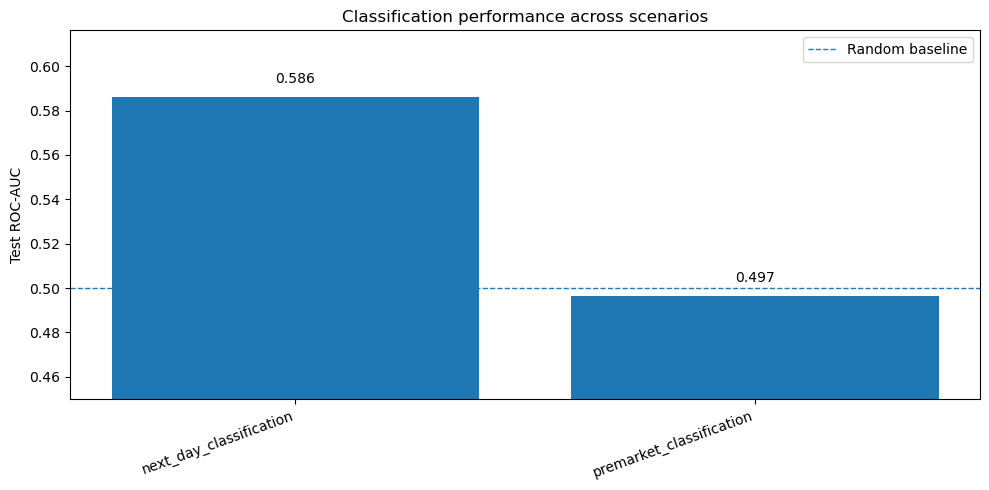

In [58]:
# 2) Main test results: classification

cls_plot = (
    all_test_results[all_test_results["task"] == "classification"]
    .copy()
    .sort_values("test_roc_auc", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(cls_plot))

ax.bar(x, cls_plot["test_roc_auc"])

# Random baseline for ROC-AUC
ax.axhline(
    0.50,
    linestyle="--",
    linewidth=1,
    label="Random baseline"
)

ax.set_xticks(x)
ax.set_xticklabels(
    cls_plot["scenario"],
    rotation=20,
    ha="right"
)

ax.set_ylabel("Test ROC-AUC")
ax.set_title("Classification performance across scenarios")
ax.set_ylim(0.45, max(0.60, cls_plot["test_roc_auc"].max() + 0.03))

for i, v in enumerate(cls_plot["test_roc_auc"]):
    if pd.notna(v):
        ax.text(
            i,
            v + 0.005,
            f"{v:.3f}",
            ha="center",
            va="bottom"
        )

ax.legend()
plt.tight_layout()
plt.show()

### Interpretation of Plot 1: Classification performance across scenarios

This plot compares the final test ROC-AUC of the two classification settings. The **next-day classification** model clearly performs better, with a ROC-AUC of **0.586**, while the **premarket classification** model is essentially at chance level with a ROC-AUC of **0.497**. This indicates that the next-day setup contains a modest directional signal, whereas the premarket setup does not provide reliable predictive value.

The main conclusion is that **predicting next-day market direction is somewhat more feasible than predicting same-day direction from premarket information**, although the overall predictive strength remains limited.

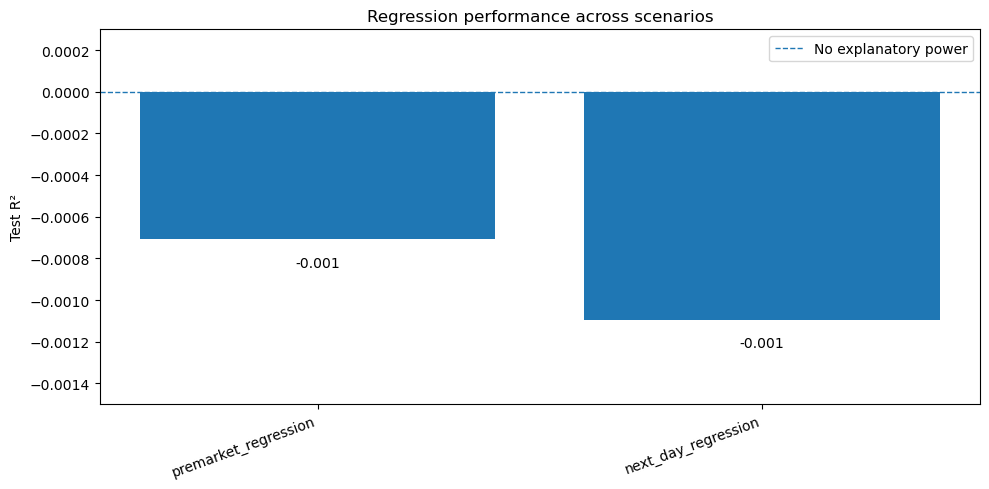

In [60]:
# 3) Main test results: regression

reg_plot = (
    all_test_results[all_test_results["task"] == "regression"]
    .copy()
    .sort_values("test_r2", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(reg_plot))
bars = ax.bar(x, reg_plot["test_r2"])

# Zero baseline for R²
ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1,
    label="No explanatory power"
)

ax.set_xticks(x)
ax.set_xticklabels(
    reg_plot["scenario"],
    rotation=20,
    ha="right"
)

ax.set_ylabel("Test R²")
ax.set_title("Regression performance across scenarios")

# Tight but readable scale around the observed negative R² values
r2_min = reg_plot["test_r2"].min()
r2_max = reg_plot["test_r2"].max()

ax.set_ylim(
    min(r2_min - 0.0003, -0.0015),
    max(r2_max + 0.0003, 0.0003)
)

for bar, v in zip(bars, reg_plot["test_r2"]):
    ax.annotate(
        f"{v:.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, v),
        xytext=(0, -12),
        textcoords="offset points",
        ha="center",
        va="top"
    )

ax.legend()
plt.tight_layout()
plt.show()

### Interpretation of Plot 2: Regression performance across scenarios

This plot shows the final test R² values for the two regression tasks. Both **next-day regression** and **premarket regression** perform poorly, with R² values slightly below zero. A negative R² means that the model performs worse than a simple baseline that predicts the average return.

This confirms that the modelling setup is **not able to predict return magnitude reliably**. While the classification results suggest a weak directional signal, there is no useful signal for predicting the size of S&P 500 returns.

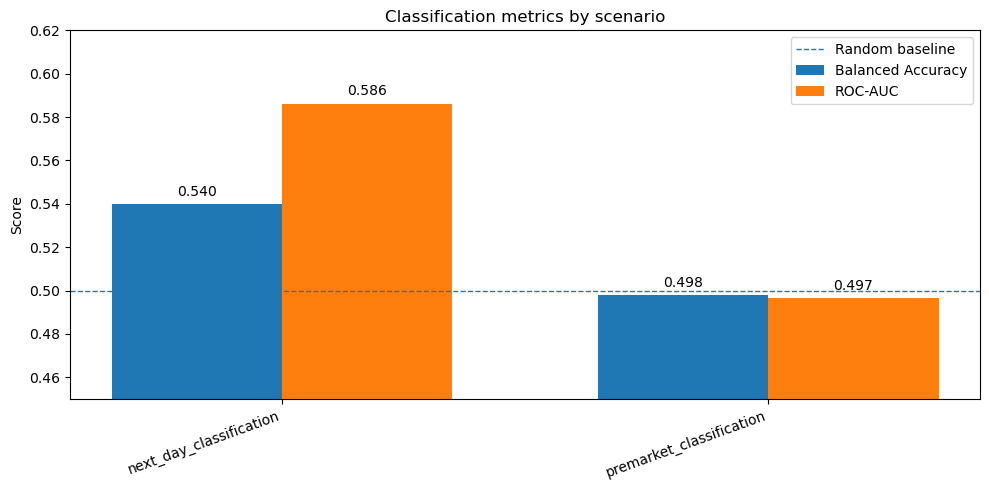

In [61]:
# 4) Main test results: balanced accuracy vs ROC-AUC

cls_compare = (
    all_test_results[all_test_results["task"] == "classification"]
    .copy()
    .sort_values("test_roc_auc", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(cls_compare))
width = 0.35

bars_bal = ax.bar(
    x - width / 2,
    cls_compare["test_balanced_accuracy"],
    width,
    label="Balanced Accuracy"
)

bars_auc = ax.bar(
    x + width / 2,
    cls_compare["test_roc_auc"],
    width,
    label="ROC-AUC"
)

ax.axhline(
    0.50,
    linestyle="--",
    linewidth=1,
    label="Random baseline"
)

ax.set_xticks(x)
ax.set_xticklabels(
    cls_compare["scenario"],
    rotation=20,
    ha="right"
)

ax.set_ylabel("Score")
ax.set_title("Classification metrics by scenario")
ax.set_ylim(
    0.45,
    max(
        0.62,
        cls_compare[["test_balanced_accuracy", "test_roc_auc"]].max().max() + 0.03
    )
)

for bars in [bars_bal, bars_auc]:
    for bar in bars:
        height = bar.get_height()

        if pd.notna(height):
            ax.annotate(
                f"{height:.3f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom"
            )

ax.legend()
plt.tight_layout()
plt.show()

### Interpretation of Plot 3: Balanced accuracy vs ROC-AUC

This plot compares the final classification performance using balanced accuracy and ROC-AUC. The **next-day classification** model performs above the random baseline on both metrics, with a balanced accuracy of **0.540** and a ROC-AUC of **0.586**, indicating a modest directional signal. The **premarket classification** model performs at chance level, with balanced accuracy of **0.498** and ROC-AUC of **0.497**.

Overall, the next-day setup shows limited but visible predictive value, while the premarket setup does not provide reliable classification performance.

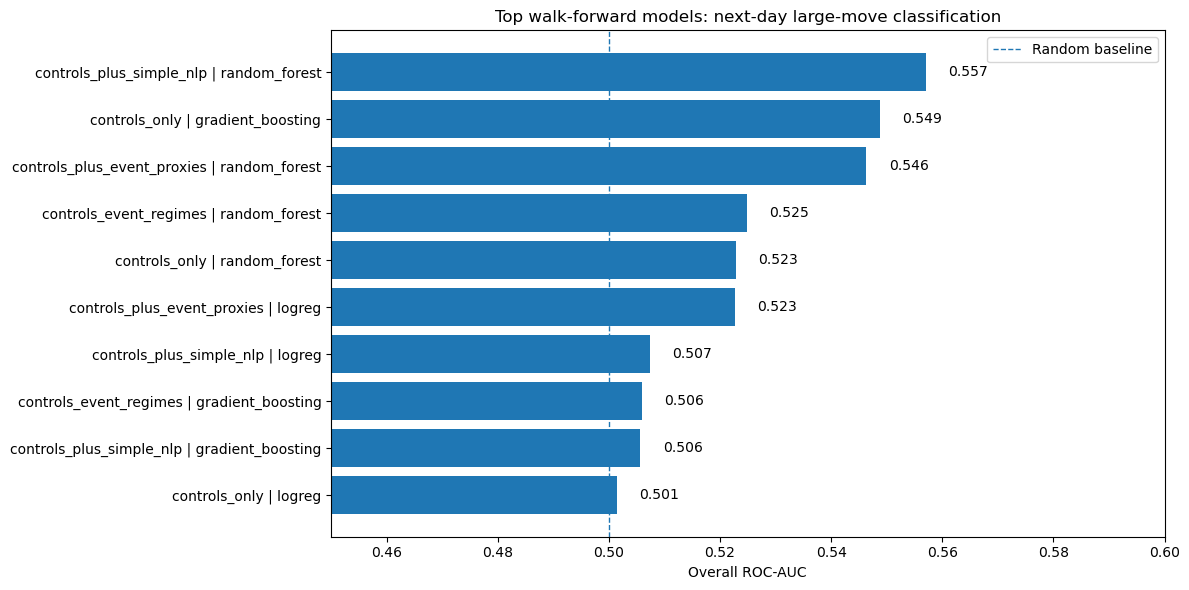

In [62]:
# 5) Advanced walk-forward results: next-day large-move classification

if "wf_next_all_summary" in globals() and isinstance(wf_next_all_summary, pd.DataFrame) and not wf_next_all_summary.empty:
    plot_df = (
        wf_next_all_summary
        .copy()
        .sort_values("overall_roc_auc", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    plot_df["label"] = plot_df["feature_set"] + " | " + plot_df["model"]

    fig, ax = plt.subplots(figsize=(12, 6))

    y = np.arange(len(plot_df))

    ax.barh(y, plot_df["overall_roc_auc"])
    ax.axvline(
        0.50,
        linestyle="--",
        linewidth=1,
        label="Random baseline"
    )

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["label"])
    ax.invert_yaxis()

    ax.set_xlabel("Overall ROC-AUC")
    ax.set_title("Top walk-forward models: next-day large-move classification")

    x_max = max(0.60, plot_df["overall_roc_auc"].max() + 0.03)
    ax.set_xlim(0.45, x_max)

    for i, v in enumerate(plot_df["overall_roc_auc"]):
        if pd.notna(v):
            ax.text(
                v + 0.004,
                i,
                f"{v:.3f}",
                va="center"
            )

    ax.legend()
    plt.tight_layout()
    plt.show()

else:
    print("wf_next_all_summary is not available or is empty.")

### Interpretation of Plot 4: Top walk-forward models for next-day large-move classification

This plot shows the best walk-forward models for predicting the direction of large next-day S&P 500 moves. The strongest model is a **Random Forest** using the `controls_plus_simple_nlp` feature set, reaching an overall ROC-AUC of **0.557**. This is above the random baseline of 0.50, but still only indicates a modest predictive signal.

The results suggest that focusing on large next-day moves improves the signal-to-noise ratio compared with the broader baseline setup. However, adding event-proxy or regime features does not clearly outperform the simpler NLP-enhanced specification. Overall, the advanced setup provides slightly stronger evidence of directional predictability, but the effect remains limited rather than strong.

In [63]:
# 6) Compare best all-days vs event-days models

comparison_rows = []

if "wf_next_all_summary" in globals() and isinstance(wf_next_all_summary, pd.DataFrame) and not wf_next_all_summary.empty:
    row = wf_next_all_summary.iloc[0].copy()
    row["sample"] = "all_days"
    comparison_rows.append(row)

if "wf_next_event_summary" in globals() and isinstance(wf_next_event_summary, pd.DataFrame) and not wf_next_event_summary.empty:
    row = wf_next_event_summary.iloc[0].copy()
    row["sample"] = "event_days_only"
    comparison_rows.append(row)

if comparison_rows:
    advanced_sample_comparison = pd.DataFrame(comparison_rows)

    cols_to_show = [
        "sample",
        "feature_set",
        "model",
        "n_predictions",
        "n_folds",
        "overall_accuracy",
        "overall_balanced_accuracy",
        "overall_roc_auc"
    ]

    display(advanced_sample_comparison[cols_to_show])
else:
    print("No walk-forward summary tables available for comparison.")

,sample,feature_set,model,n_predictions,n_folds,overall_accuracy,overall_balanced_accuracy,overall_roc_auc
0,all_days,controls_plus_simple_nlp,random_forest,271,4,0.586716,0.563554,0.557080
0,event_days_only,controls_event_regimes,logreg,38,1,0.473684,0.497222,0.558333


### All days vs event days

The comparison shows that the **all-days** large-move model is more reliable than the **event-days-only** model. The all-days model uses `controls_plus_simple_nlp` with Random Forest and achieves a ROC-AUC of **0.557**, balanced accuracy of **0.564**, and 271 predictions across 4 folds. The event-days-only model has a similar ROC-AUC of **0.558**, but it is based on only 38 predictions and 1 fold, with lower accuracy and balanced accuracy around **0.497**.

Therefore, the event-day restriction should not be interpreted as stronger evidence of predictive power. The safer conclusion is that focusing on **large next-day moves** improves the signal somewhat, but restricting further to economically relevant event days leaves too little data for a robust result.

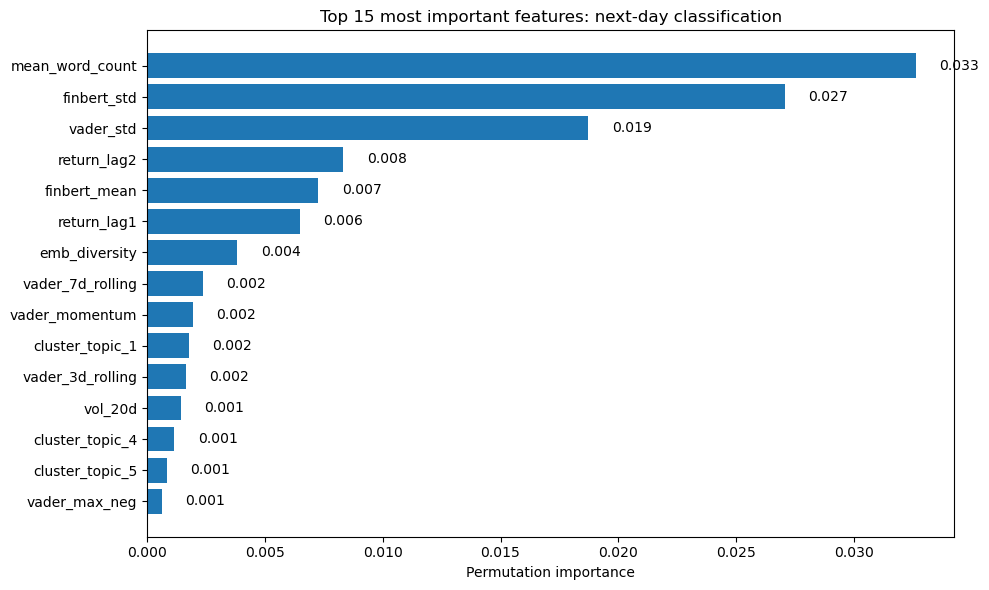

In [64]:
# 9) Feature importance of the best next-day classification model

if (
    "importance_table_next_day_classification" in globals()
    and isinstance(importance_table_next_day_classification, pd.DataFrame)
    and not importance_table_next_day_classification.empty
):
    plot_df = (
        importance_table_next_day_classification
        .head(15)
        .copy()
        .sort_values("importance_mean")
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.barh(
        plot_df["feature"],
        plot_df["importance_mean"]
    )

    ax.set_xlabel("Permutation importance")
    ax.set_title("Top 15 most important features: next-day classification")

    for i, v in enumerate(plot_df["importance_mean"]):
        ax.text(
            v + 0.001,
            i,
            f"{v:.3f}",
            va="center"
        )

    plt.tight_layout()
    plt.show()

else:
    print("importance_table_next_day_classification is not available yet.")

### Feature importance of the best next-day classification model

This plot shows the permutation importance of the strongest next-day classification model. Permutation importance measures how much model performance declines when one feature is randomly shuffled while all other features remain unchanged. Larger values therefore indicate that the model depends more strongly on that feature.

The most important feature is `mean_word_count`, followed by sentiment dispersion measures such as `finbert_std` and `vader_std`. Lagged market controls, especially `return_lag2` and `return_lag1`, also contribute to the model. In contrast, topic and cluster features have much smaller importance values. This suggests that the model’s weak predictive signal is driven mainly by text length, sentiment variability, and recent market dynamics rather than by individual topic indicators.